[Land sea mask loader]
Elapsed: 0.20733380317687988


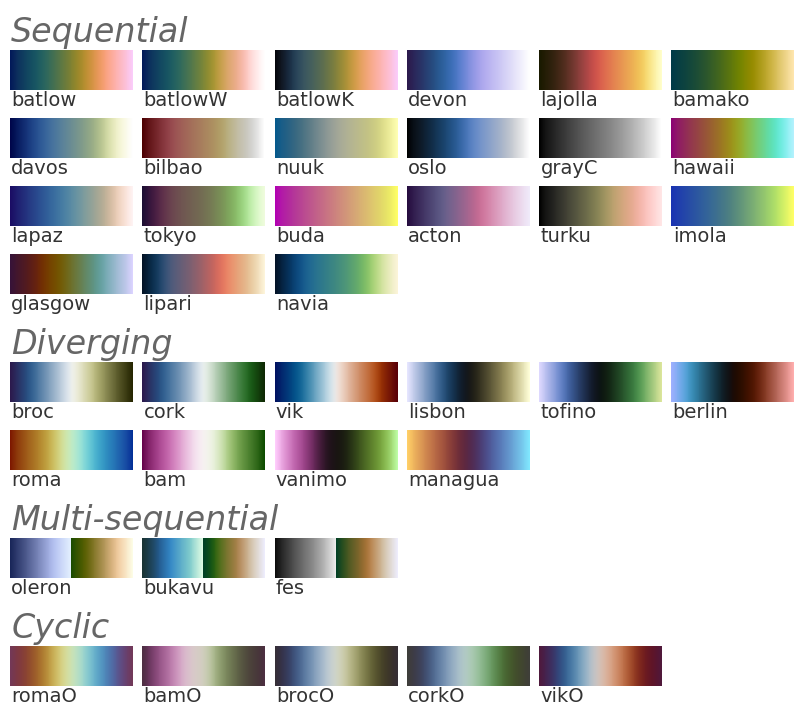

In [1]:
#Define my working directory (important for modules)
import os
os.chdir('/nfs/mary/Users/eelse/scripts/jupyter')

%matplotlib inline
import xarray as xr
import cartopy.feature
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, TwoSlopeNorm, LinearSegmentedColormap, ListedColormap, Normalize
import cmcrameri.cm as cmc

import numpy as np

import mw_protocol.plotting as plotting
import mw_protocol.glac1d_toolbox as tb

import mymodules.myfunc as mf 

import cftime
import regionmask
import geopandas as gpd
import pandas as pd
import pickle

#landmask
with mf.Timer('Land sea mask loader'):
    data_folder = f"/nfs/annie/eeymr/work/data/publication/ROME2022_paleoceanography_oscillations"
    ds_lsm = xr.open_dataset(f"{data_folder}/lgm_inputs/temev.qrparm.omask.nc")
    lsm = ds_lsm.lsm

from cmcrameri import show_cmaps
show_cmaps()


# Load / Generate Data

In [2]:
# Make or Load the Mean Dyefield Computation 

from mymodules.dyefield_computation import run_pipeline
from myconfig.EXPERIMENTS import EXPERIMENTS

results = run_pipeline(
    experiments=EXPERIMENTS,
    outdir="myintermediates/dyestuff_modelpaper/",
    keep_in_memory=True, # put it in my jupyter Notebook memory
    save=True,
    overwrite=False, # If the data is already there - do not overwrite but just lazy load the existing files
    exclude=('xqeic','xqeie'), #simulations to be excluded here from the total experiments
    preflight=False, #You need to make this false if you don't need it, else it takes time!
)




===== COLD =====


cold: 100%|███████████████████████████████| 5/5 [00:00<00:00,  8.97experiment/s]



===== MERID =====


merid: 100%|██████████████████████████████| 4/4 [00:00<00:00, 13.10experiment/s]



===== ZONAL =====


zonal: 100%|██████████████████████████████| 4/4 [00:00<00:00, 19.91experiment/s]


✓ Pipeline finished.


In [3]:
# Dye and d18O information
from myconfig.DYES import DYE_TABLE
DYE_TO_REGION = dict(zip(DYE_TABLE["dye"], DYE_TABLE["region"]))

gdg = pd.read_pickle("myintermediates/regionalmeltdischarge_withd18O.pkl")

gdg['Newnames'] = DYE_TABLE["region"]

lookup = {}
lookup_dis = {}
lookup_min = {}
lookup_max = {}

for sce in ['17.8ka','18.2 ka','19.4 ka','20.7 ka']:
    lookup[sce] = mf.build_d18O_lookup(
        gdg,
        column=f"mean (-35.0) region d18O anomaly {sce}")

    lookup_min[sce] = mf.build_d18O_lookup(
        gdg,
        column=f"max (-30.0) region d18O anomaly {sce}")

    lookup_max[sce] = mf.build_d18O_lookup(
        gdg,
        column=f"min (-40.0) region d18O anomaly {sce}")

    lookup_dis[sce] = mf.build_d18O_lookup(
        gdg,
        column=f"Region Melt {sce} (Sv)")
    


new_keys = ['17.8k', '18.2k', '19.4k', '20.7k']
lookup = dict(zip(new_keys, lookup.values()))
lookup_dis = dict(zip(new_keys, lookup_dis.values())) #in mSv
lookup_min = dict(zip(new_keys, lookup_min.values()))
lookup_max = dict(zip(new_keys, lookup_max.values())) #in mSv


#Regions
ds_dyeregion = xr.open_dataset('myintermediates/dyestuff_modelpaper/dye_regions_norm.nc')
dyen = list(ds_dyeregion.data_vars)

dye_colors = {'dye00':'tab:blue', 'dye01':'tab:orange', 'dye02':'tab:green', 'dye03':'tab:red', 'dye04':'tab:purple', 'dye05':'tab:brown', 'dye06':'tab:pink',
         'dye07':'tab:olive', 'dye08':'tab:cyan'}



In [8]:
from mymodules.d18O_computation import build_d18O_results
from mymodules.d18O_computation import compute_d18O



#EXPERIMENTS # for conversion


#for state, scenarios in EXPERIMENTS.items():
#
#    exp = EXPERIMENTS[state][scenarios]['exp']
#    ds = results[state][exp] 
#    ds_d18O = compute_d18O(ds, lookup[scenarios], dyes=None)

d18O_results = build_d18O_results(
    experiments=EXPERIMENTS,
    result_input=results,
    d18O_lookup=lookup,
    outdir="myintermediates/dyestuff_modelpaper/",
    keep_in_memory=True, # put it in my jupyter Notebook memory
    save=True,
    suffix="_mean",
    overwrite=False, # If the data is already there - do not overwrite but just lazy load the existing files
    exclude=('xqeic','xqeie','xpujm'), #simulations to be excluded here from the total experiments (I add xpujm here because it has not enough years in merid mode
)

d18O_results_min = build_d18O_results(
    experiments=EXPERIMENTS,
    result_input=results,
    d18O_lookup=lookup_min,
    outdir="myintermediates/dyestuff_modelpaper/min/",
    keep_in_memory=True, # put it in my jupyter Notebook memory
    save=True,
    suffix="_mean",
    overwrite=False, # If the data is already there - do not overwrite but just lazy load the existing files
    exclude=('xqeic','xqeie','xpujm'), #simulations to be excluded here from the total experiments (I add xpujm here because it has not enough years in merid mode
)

d18O_results_max = build_d18O_results(
    experiments=EXPERIMENTS,
    result_input=results,
    d18O_lookup=lookup_max,
    outdir="myintermediates/dyestuff_modelpaper/max/",
    keep_in_memory=True, # put it in my jupyter Notebook memory
    save=True,
    suffix="_mean",
    overwrite=False, # If the data is already there - do not overwrite but just lazy load the existing files
    exclude=('xqeic','xqeie','xpujm'), #simulations to be excluded here from the total experiments (I add xpujm here because it has not enough years in merid mode
)






cold:   0%|                                               | 0/5 [00:00<?, ?it/s]
                                                                                
Ocean states: 100%|███████████████████████████████| 3/3 [00:02<00:00,  1.16it/s]


In [9]:
d18O_results_min['cold']['xpujf']['d18O'].values

array([[[ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [-0.35534863, -0.35615413, -0.35697804, ..., -0.3530706 ,
         -0.35380657, -0.35456559],
        [-0.35974865, -0.36017118, -0.36059057, ..., -0.35848209,
         -0.3589014 , -0.35932458],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ]],

       [[ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [-0.35523556, -0.35603872, -0.3568603 , ..., -

In [10]:
d18O_results_max['cold']['xpujf']['d18O'].values

array([[[ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [-0.47379818, -0.47487218, -0.47597072, ..., -0.4707608 ,
         -0.47174209, -0.47275412],
        [-0.47966486, -0.48022824, -0.48078742, ..., -0.47797612,
         -0.4785352 , -0.47909944],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ]],

       [[ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [-0.47364742, -0.4747183 , -0.47581373, ..., -

In [24]:
from tqdm import tqdm


lon_min, lon_max = -80, 0
lat_min, lat_max = 20, 65


def build_d18O_mean_lookup(
    experiments,
    d18O_results,
    lon_min,lon_max,
    lat_min,lat_max,
    lsm=None,
    scenarios=("17.8k", "18.2k", "19.4k", "20.7k"),
):
    """
    Precompute area-weighted mean d18O per mode & scenario.
    Skips missing experiments safely.
    """

    mean_lookup = {}
    mean_lookup_old = {}

    # cosine latitude weights (precompute once)
    #weights = np.cos(np.deg2rad(lat))
    #weights = xr.DataArray(weights, coords={lat.name: lat}, dims=[lat.name])

    for mode, scen_dict in tqdm(experiments.items(), desc="modes"):

        mean_lookup[mode] = {}
        mean_lookup_old[mode] = {}

        for scenario in scenarios:

            # -----------------------------------------
            # skip missing scenario (IMPORTANT)
            # -----------------------------------------
            if scenario not in scen_dict:
                continue

            exp = scen_dict[scenario]["exp"]

            # -----------------------------------------
            # skip missing computed results
            # -----------------------------------------
            #if exp not in d18O_results[mode]:
            #    continue


            # -----------------------------------------
            # handle both d18O simulated and predicted fields
            # -----------------------------------------

            field = None

            if exp in d18O_results[mode]:
                print("Using experiment format for", exp)
                field = d18O_results[mode][exp]["d18O"].isel(depth_1=0)
            
            else:
                pred_key = f"{scenario}_d18O_mean"
                print("Looking for", pred_key)
            
                if pred_key in d18O_results[mode]:
                    print("Found prediction")
                    field = d18O_results[mode][pred_key]
                else:
                    print("Not found!")
                    continue

            


            #field = d18O_results[mode][exp]["d18O"].isel(depth_1=0)

            # ---
            # Apply land-sea mask
            # ---

            
            if lsm is not None:
                field = xr.where(lsm==0, field,np.nan) 
            

            # -----------------------------------------
            # area-weighted mean
            # -----------------------------------------

            # Detect coordinate names
            lat_name = "latitude" if "latitude" in field.coords else "lat"
            lon_name = "longitude" if "longitude" in field.coords else "lon"

            # -----------------------------------------
            # Handle longitude convention
            # -----------------------------------------
            
            lon_values = field[lon_name]
            
            # data uses 0-360 convention
            if lon_values.max() > 180:
            
                lon_min_sel = lon_min % 360
                lon_max_sel = lon_max % 360
            
            else:
                lon_min_sel = lon_min
                lon_max_sel = lon_max


            if lon_min_sel <= lon_max_sel:

                region = field.sel(
                    {
                        lon_name: slice(lon_min_sel, lon_max_sel),
                        lat_name: slice(lat_min, lat_max),
                    }
                )
            
            else:
                # region crosses 0/360 boundary
                region = xr.concat(
                    [
                        field.sel({lon_name: slice(lon_min_sel, 360),
                                   lat_name: slice(lat_min, lat_max)}),
                        field.sel({lon_name: slice(0, lon_max_sel),
                                   lat_name: slice(lat_min, lat_max)})
                    ],
                    dim=lon_name
                )


            # Apply Area-Weighting
            weights = np.cos(np.deg2rad(region[lat_name]))

            mean_val = float(
                region.weighted(weights).mean().compute()
                )

            mean_val_old = float(
                region.mean().compute()
                )

            #mean_val = region.weighted(weights).mean().item()
            #mean_val_old = region.mean().item()

            mean_lookup[mode][scenario] = mean_val
            mean_lookup_old[mode][scenario] = mean_val_old


    return mean_lookup, mean_lookup_old


mean_lookup, mean_lookup_old = build_d18O_mean_lookup(
    experiments=EXPERIMENTS,
    d18O_results=d18O_results,
    lon_min=lon_min,
    lon_max=lon_max,
    lat_min=lat_min,
    lat_max=lat_max,
    lsm=lsm,
)





modes: 100%|██████████████████████████████████████| 3/3 [00:00<00:00, 25.51it/s]

Using experiment format for xpraj
Using experiment format for xpujl
Using experiment format for xpuji
Using experiment format for xpujf
Using experiment format for xpral
Looking for 18.2k_d18O_mean
Not found!
Using experiment format for xpujj
Using experiment format for xpujg
Using experiment format for xprak
Using experiment format for xpujk
Using experiment format for xpujh


In [25]:
# Load Mean values for prediction data sets.
# Test of the old vs new way of computing the mean values

# Load Dyes

ds_dye_zonal = xr.open_dataset('myintermediates/dyestuff_modelpaper/mean_dye_zonal.nc')
ds_dye_cold = xr.open_dataset('myintermediates/dyestuff_modelpaper/mean_dye_cold.nc')
ds_dye_merid = xr.open_dataset('myintermediates/dyestuff_modelpaper/mean_dye_merid.nc')


dict_dye = {'zonal' : ds_dye_zonal,
     'cold' : ds_dye_cold,
     'merid' : ds_dye_merid
    }

gdf_list = ['17.8ka','18.2 ka','19.4 ka','20.7 ka']

for mode, ds_dye in dict_dye.items():

    for j in range(4):
        for i in range(9):
            ds_dye[f'{gdf_list[j]} dye0{i} d18O'] = ds_dye[f'dye0{i}']*gdg[f'mean (-35.0) region d18O anomaly {gdf_list[j]}'][i]
        
        ds_dye[f'{gdf_list[j]} total d18O'] = ds_dye[f'{gdf_list[j]} dye00 d18O'] + ds_dye[f'{gdf_list[j]} dye01 d18O'] + ds_dye[f'{gdf_list[j]} dye02 d18O'] + ds_dye[f'{gdf_list[j]} dye03 d18O'] + ds_dye[f'{gdf_list[j]} dye04 d18O'] + ds_dye[f'{gdf_list[j]} dye05 d18O'] + ds_dye[f'{gdf_list[j]} dye06 d18O'] + ds_dye[f'{gdf_list[j]} dye07 d18O'] + ds_dye[f'{gdf_list[j]} dye08 d18O']


d18O_results_predict = {}

scenarios_old = ["17.8ka", "18.2 ka", "19.4 ka", "20.7 ka"]
scenarios_new = ["17.8k", "18.2k", "19.4k", "20.7k"]


for mode in dict_dye:

    d18O_results_predict[mode] = {}

    for j,scen in enumerate(scenarios_old):

        old_key = f"{scen} total d18O"

        if old_key not in dict_dye[mode]:
            continue

        new_key = f"{scenarios_new[j]}_d18O_mean"

        d18O_results_predict[mode][new_key] = dict_dye[mode][old_key]


from myconfig.EXPERIMENTS_prediction import EXPERIMENTS_prediction

mean_predict_lookup, mean_predict_lookup_old = build_d18O_mean_lookup(
    experiments=EXPERIMENTS_prediction,
    d18O_results=d18O_results_predict,
    lon_min=lon_min,
    lon_max=lon_max,
    lat_min=lat_min,
    lat_max=lat_max,
)


modes: 100%|██████████████████████████████████████| 3/3 [00:00<00:00, 45.46it/s]

Looking for 17.8k_d18O_mean
Found prediction
Looking for 18.2k_d18O_mean
Found prediction
Looking for 19.4k_d18O_mean
Found prediction
Looking for 20.7k_d18O_mean
Found prediction
Looking for 17.8k_d18O_mean
Found prediction
Looking for 18.2k_d18O_mean
Found prediction
Looking for 19.4k_d18O_mean
Found prediction
Looking for 20.7k_d18O_mean
Found prediction
Looking for 17.8k_d18O_mean
Found prediction
Looking for 18.2k_d18O_mean
Found prediction
Looking for 19.4k_d18O_mean
Found prediction
Looking for 20.7k_d18O_mean
Found prediction


## Figure 5: d18O Scenario Maps
 1) From Single Runs
 2) Projected from Mean

In [18]:
#Libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
from matplotlib.patches import Patch

import matplotlib.patches as mpatches
from matplotlib import colors

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap
import matplotlib as mpl
import matplotlib.path as mpath
import matplotlib.patches as mpatches
from scipy.ndimage import gaussian_filter

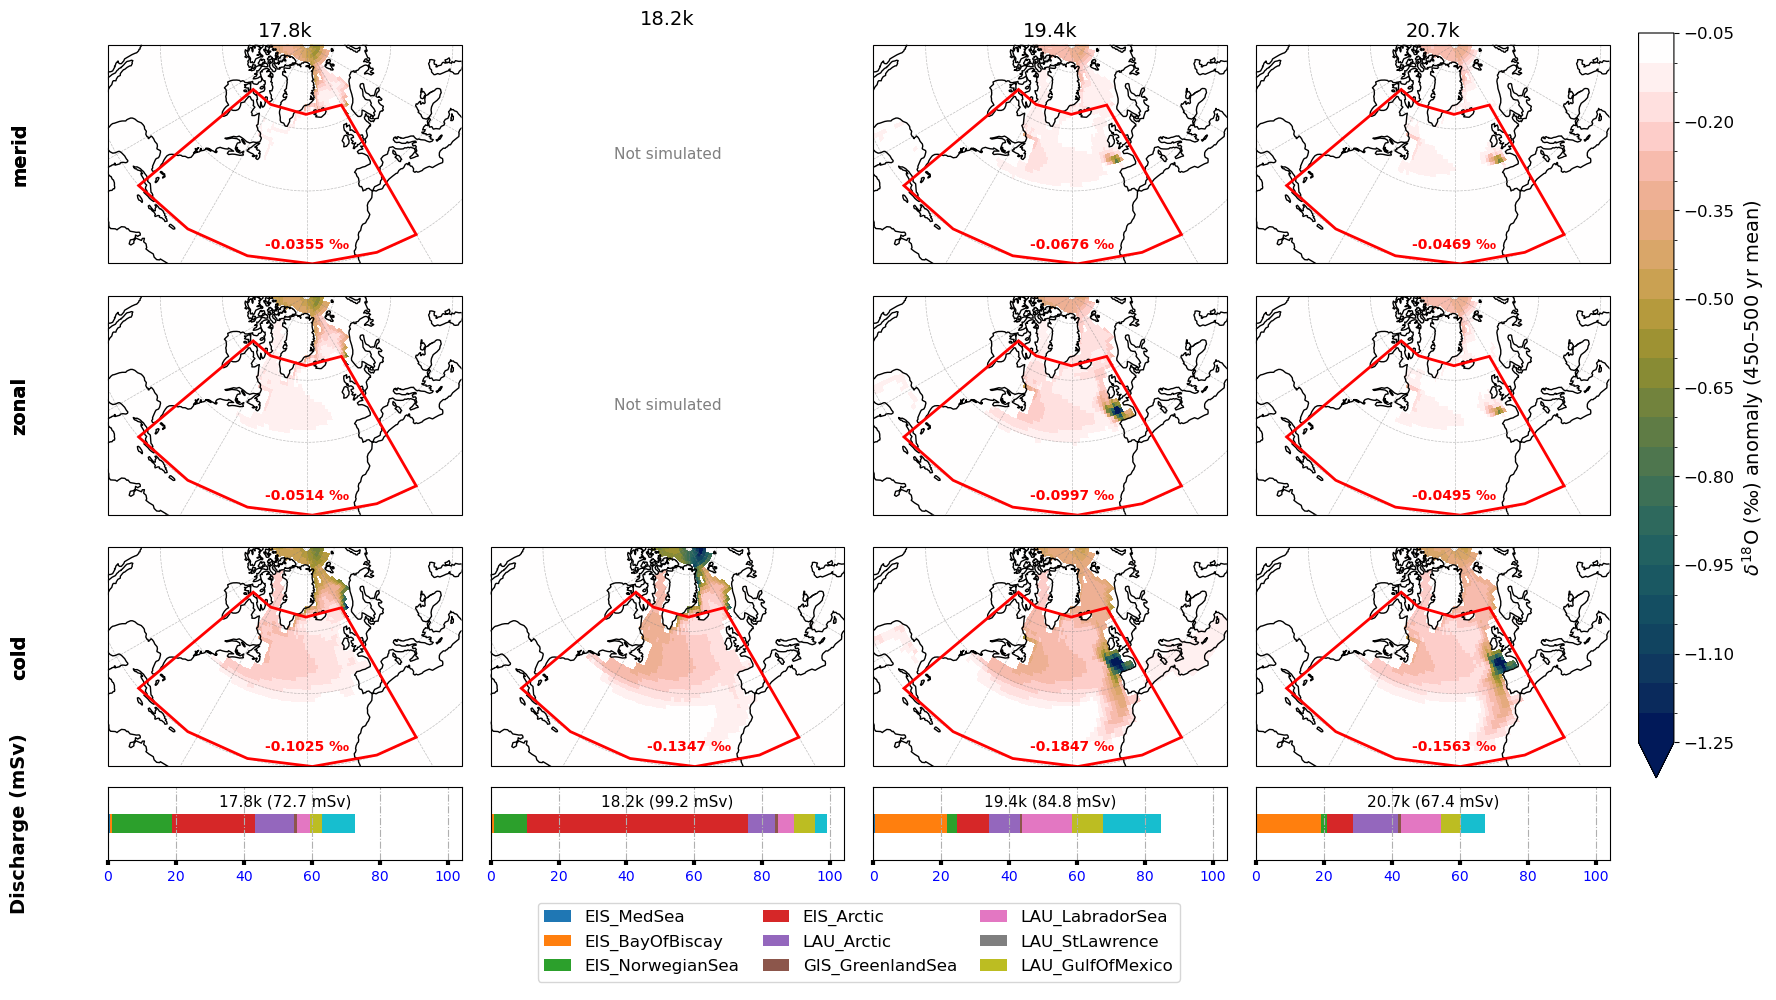

In [19]:
# 1. From Single Runs


# Boundary Boxes
lon_dis, lat_dis = ds_dyeregion.longitude.values, ds_dyeregion.latitude.values
lon_dis_b, lat_dis_b = tb.create_coordinate_edges(lon_dis), tb.create_coordinate_edges(lat_dis)


# -----------------------------
# CONFIGURATION
# -----------------------------
modes = ["merid", "zonal", "cold"]
scenarios = ["17.8k", "18.2k", "19.4k", "20.7k"]

scale_Sv_to_mSv = 1000

region_names = list(lookup_dis["17.8k"].keys())

# -----------------------------
# FIGURE + GRID
# -----------------------------

projection_map = ccrs.NorthPolarStereo(central_longitude=-30)
#projection_map = ccrs.PlateCarree(central_longitude=-30)

#axMap = axMap.flatten()
normdye = colors.Normalize(vmin=0,vmax=0.05)
normd18O = colors.Normalize(vmin=0,vmax=-1.)
normdyediff = colors.TwoSlopeNorm(vmin=-0.05, vcenter=0., vmax=0.05)

# --- Discrete colormap ---
bounds = np.arange(-1.25, 0, 0.05)
normdye18O_a = mpl.colors.BoundaryNorm(boundaries=bounds, ncolors=cmc.batlowW.N)



fig = plt.figure(figsize=(18, 11))

gs = gridspec.GridSpec(
    nrows=5,
    ncols=5,
    figure=fig,
    width_ratios=[1, 1, 1, 1, 0.1],
    height_ratios=[1, 1, 1, 0.3,0.5],
    wspace=0.1,
    hspace=0.05,
)

# map axes
axMap = np.empty((3, 4), dtype=object)
axBar = np.empty((1,4), dtype=object)
axBarLegend = np.empty((1,5), dtype=object)


for i, mode in enumerate(modes):
    for j, scen in enumerate(scenarios):
        axMap[i, j] = fig.add_subplot(
            gs[i, j],
            projection=projection_map
        )

bar_axes = [
    fig.add_subplot(gs[3, j])
    for j in range(4)
]


# colorbar axis
cax = fig.add_subplot(gs[:3, 4])


# legend
legend_ax = fig.add_subplot(gs[4,:4])
legend_ax.axis("off")

# bar axis (bottom panel already part of same figure)
# ------------------------------------------------------------------
# Bottom section: nested GridSpec
# ------------------------------------------------------------------


# -----------------------------
# MAP PLOTTING
# -----------------------------
im = None

for i, mode in enumerate(modes):
    for j, scen in enumerate(scenarios):

        ax = axMap[i, j]
        ax.grid(True)

        if scen not in EXPERIMENTS[mode]:
            ax.set_xticks([])
            ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_visible(False)
    
            ax.text(
                0.5, 0.5,
                "Not simulated",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=11,
                color="0.5",
            )
            continue

        exp = EXPERIMENTS[mode][scen]["exp"]

        if exp not in d18O_results[mode]:
            ax.set_xticks([])
            ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_visible(False)
    
            ax.text(
                0.5, 0.5,
                "Not simulated",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=11,
                color="0.5",
            )
            continue

        field = d18O_results[mode][exp]["d18O"].isel(depth_1=0)

        avg_val = mean_lookup[mode][scen]

        im = ax.pcolormesh(
            lon_dis_b,
            lat_dis_b,
            field,
            transform=ccrs.PlateCarree(),
            cmap=cmc.batlowW,
            norm=normdye18O_a,
            shading="nearest",
        )

        # gridlines
        gl = ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=False,
            linewidth=0.5,
            color="gray",
            alpha=0.5,
            linestyle="--",
        )

        # add red rectangle
        width = lon_max - lon_min
        height = lat_max - lat_min
        rect = mpatches.Rectangle(
            (lon_min, lat_min), width, height,
            linewidth=2, edgecolor='red', facecolor='none',
            transform=ccrs.PlateCarree(), zorder=50
        )
        axMap[i,j].add_patch(rect)

        # --- add average value inside the rectangle (bottom-right corner) ---
        axMap[i,j].text(
            -30, 25, f"{avg_val:.4f} ‰",  # place at bottom-right of rectangle
            color='red', fontsize=10, fontweight='bold',
            ha='center', va='center',
            transform=ccrs.PlateCarree(),
            zorder=60
        )


        ax.coastlines(zorder=10)
        ax.set_extent([-95, 15, 20, 90], crs=ccrs.PlateCarree())

# -----------------------------
# COLUMN TITLES
# -----------------------------
for j, scen in enumerate(scenarios):
    axMap[0, j].set_title(scen, fontsize=14, loc="center")

# -----------------------------
# ROW LABELS
# -----------------------------
for i, mode in enumerate(modes):
    axMap[i, 0].text(
        -0.25, 0.5,
        mode,
        rotation=90,
        transform=axMap[i, 0].transAxes,
        va="center",
        ha="center",
        fontsize=14,
        fontweight="bold",
    )



#for i, mode in enumerate(modes):

# -----------------------------
# COLUMN TITLES
# -----------------------------
for j, scen in enumerate(scenarios):
    axMap[0, j].set_title(scen, fontsize=14, loc="center")

# -----------------------------
# ROW LABELS
# -----------------------------
for i, mode in enumerate(modes):
    axMap[i, 0].text(
        -0.25, 0.5,
        mode,
        rotation=90,
        transform=axMap[i, 0].transAxes,
        va="center",
        ha="center",
        fontsize=14,
        fontweight="bold",
    )

# -----------------------------
# COLORBAR
# -----------------------------
cb = fig.colorbar(im, cax=cax, orientation="vertical", extend='min',shrink=0.6)
cb.set_label(r"$\delta^{18}$O (‰) anomaly (450–500 yr mean)",fontsize=14)
cb.ax.tick_params(labelsize=12)


# -----------------------------
# STACKED BAR PLOT (BOTTOM)
# -----------------------------


scenario_totals = {}

for scen in scenarios:
    total = sum(
        lookup_dis[scen].get(region, 0.0)
        for region in region_names
    )
    scenario_totals[scen] = total * scale_Sv_to_mSv

# colors for consistency
#colors = plt.cm.tab10(np.linspace(0, 1, len(region_names)))

# -------------------------------------------------
# STACKED BAR PLOTS
# -------------------------------------------------
region_names = list(lookup_dis["17.8k"].keys())
colors = plt.cm.tab10(np.arange(len(region_names)))

scenario_totals = {}

for scen in scenarios:
    scenario_totals[scen] = (
        sum(lookup_dis[scen].get(r, 0.0) for r in region_names)
        * scale_Sv_to_mSv
    )

xmax = max(scenario_totals.values()) * 1.05

for j, scen in enumerate(scenarios):

    ax = bar_axes[j]

    pos = ax.get_position()

    ax.set_position([
        pos.x0+0.2,
        pos.y0 + 0.5,      # shift upward
        pos.width,
        pos.height   # make slightly shorter
    ])


    left = 0

    for i, region in enumerate(region_names):

        value = lookup_dis[scen].get(region, 0.0) * scale_Sv_to_mSv

        ax.barh(
            0,
            value,
            left=left,
            color=dye_colors[f'dye0{i}'],
        )

        left += value

    ax.set_xlim(0, xmax)
    ax.set_ylim(-1.5, 1.5)

    ax.set_title(
        f"{scen} ({scenario_totals[scen]:.1f} mSv)",
        fontsize=11,
        y=1.0, pad=-14,
        
    )

    ax.set_yticks([])
    ax.grid(True, linestyle='-.')
    ax.tick_params(labelcolor='b', labelsize='medium', width=3)

    ax.set_xlabel("")

    #for spine in ["top", "right", "left"]:
    #    ax.spines[spine].set_visible(False)


bar_axes[0].text(
        -0.25, 0.5,
        'Discharge (mSv)',
        rotation=90,
        transform=bar_axes[0].transAxes,
        va="center",
        ha="center",
        fontsize=14,
        fontweight="bold",
    )


# -------------------------------------------------
# LEGEND
# -------------------------------------------------
legend_handles = [
    Patch(
        facecolor=colors[i],
        label=DYE_TABLE.iloc[i]["region"]
    )
    for i in range(len(DYE_TABLE))
]

legend_ax.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=True,
    fontsize=12,
    columnspacing=1.4,
    handlelength=1.6,
)

# -----------------------------
# FINAL LAYOUT
# -----------------------------
plt.subplots_adjust(
    left=0.05,
    right=0.92,
    top=0.95,
    bottom=0.08,
)

# Save the Figure
plt.savefig(
    "my_output/chapter-four_latestfigures/Fig5_Rev_ScenarioMap.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)




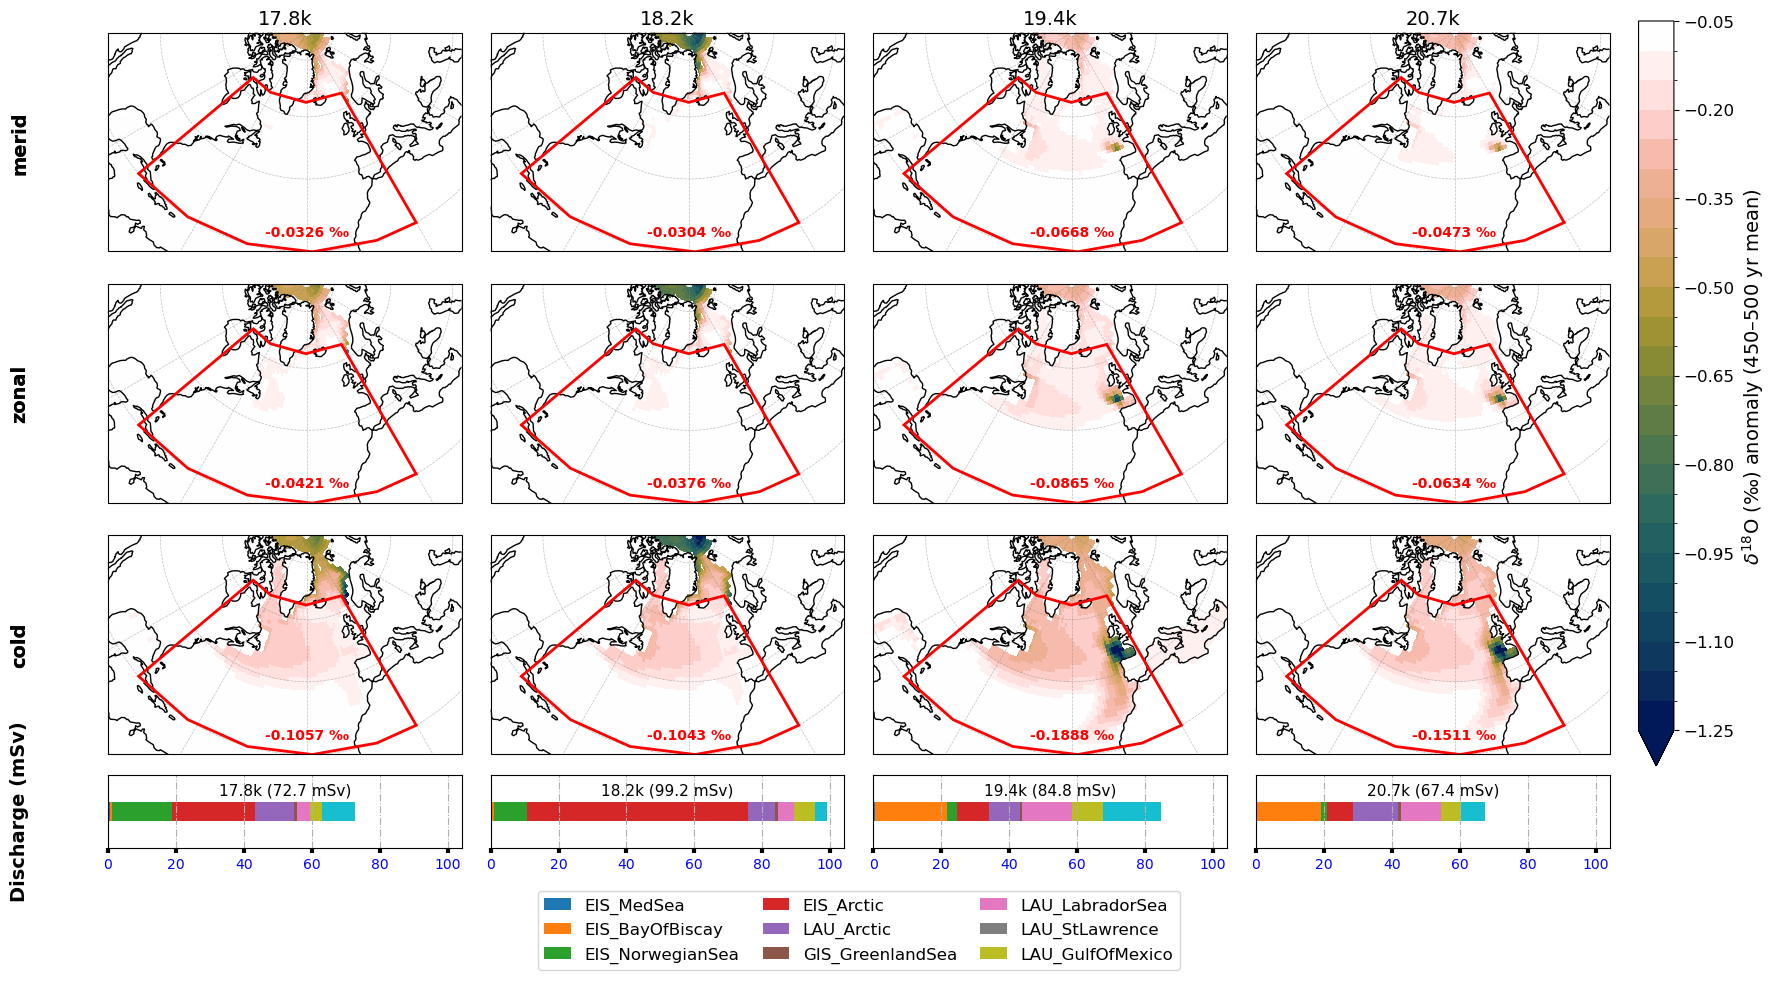

In [20]:
# 2. Predicted
from myconfig.EXPERIMENTS_prediction import EXPERIMENTS_prediction

#Libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
from matplotlib.patches import Patch

import matplotlib.patches as mpatches
from matplotlib import colors

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap
import matplotlib as mpl
import matplotlib.path as mpath
import matplotlib.patches as mpatches
from scipy.ndimage import gaussian_filter



# Boundary Boxes
lon_dis, lat_dis = ds_dyeregion.longitude.values, ds_dyeregion.latitude.values
lon_dis_b, lat_dis_b = tb.create_coordinate_edges(lon_dis), tb.create_coordinate_edges(lat_dis)


# -----------------------------
# CONFIGURATION
# -----------------------------
modes = ["merid", "zonal", "cold"]
scenarios = ["17.8k", "18.2k", "19.4k", "20.7k"]

scale_Sv_to_mSv = 1000

region_names = list(lookup_dis["17.8k"].keys())

# -----------------------------
# FIGURE + GRID
# -----------------------------

projection_map = ccrs.NorthPolarStereo(central_longitude=-30)
#projection_map = ccrs.PlateCarree(central_longitude=-30)

#axMap = axMap.flatten()
normdye = colors.Normalize(vmin=0,vmax=0.05)
normd18O = colors.Normalize(vmin=0,vmax=-1.)
normdyediff = colors.TwoSlopeNorm(vmin=-0.05, vcenter=0., vmax=0.05)

# --- Discrete colormap ---
bounds = np.arange(-1.25, 0, 0.05)
normdye18O_a = mpl.colors.BoundaryNorm(boundaries=bounds, ncolors=cmc.batlowW.N)



fig = plt.figure(figsize=(18, 11))

gs = gridspec.GridSpec(
    nrows=5,
    ncols=5,
    figure=fig,
    width_ratios=[1, 1, 1, 1, 0.1],
    height_ratios=[1, 1, 1, 0.3,0.5],
    wspace=0.1,
    hspace=0.05,
)

# map axes
axMap = np.empty((3, 4), dtype=object)
axBar = np.empty((1,4), dtype=object)
axBarLegend = np.empty((1,5), dtype=object)


for i, mode in enumerate(modes):
    for j, scen in enumerate(scenarios):
        axMap[i, j] = fig.add_subplot(
            gs[i, j],
            projection=projection_map
        )

bar_axes = [
    fig.add_subplot(gs[3, j])
    for j in range(4)
]




# colorbar axis
cax = fig.add_subplot(gs[:3, 4])


# legend
legend_ax = fig.add_subplot(gs[4,:4])
legend_ax.axis("off")

# bar axis (bottom panel already part of same figure)
# ------------------------------------------------------------------
# Bottom section: nested GridSpec
# ------------------------------------------------------------------


# -----------------------------
# MAP PLOTTING
# -----------------------------
im = None

for i, mode in enumerate(modes):
    for j, scen in enumerate(scenarios):

        ax = axMap[i, j]
        ax.grid(True)

        if scen not in EXPERIMENTS_prediction[mode]:
            ax.set_xticks([])
            ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_visible(False)
    
            ax.text(
                0.5, 0.5,
                "Not simulated",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=11,
                color="0.5",
            )
            continue

        exp = scen + "_d18O_mean"

        if exp not in d18O_results_predict[mode]:
            ax.set_xticks([])
            ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_visible(False)
    
            ax.text(
                0.5, 0.5,
                "Not simulated",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=11,
                color="0.5",
            )
            continue

        field = d18O_results_predict[mode][exp]

        avg_val = mean_predict_lookup[mode][scen]

        im = ax.pcolormesh(
            lon_dis_b,
            lat_dis_b,
            field,
            transform=ccrs.PlateCarree(),
            cmap=cmc.batlowW,
            norm=normdye18O_a,
            shading="nearest",
        )

        # gridlines
        gl = ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=False,
            linewidth=0.5,
            color="gray",
            alpha=0.5,
            linestyle="--",
        )

        # add red rectangle
        width = lon_max - lon_min
        height = lat_max - lat_min
        rect = mpatches.Rectangle(
            (lon_min, lat_min), width, height,
            linewidth=2, edgecolor='red', facecolor='none',
            transform=ccrs.PlateCarree(), zorder=50
        )
        axMap[i,j].add_patch(rect)

        # --- add average value inside the rectangle (bottom-right corner) ---
        axMap[i,j].text(
            -30, 25, f"{avg_val:.4f} ‰",  # place at bottom-right of rectangle
            color='red', fontsize=10, fontweight='bold',
            ha='center', va='center',
            transform=ccrs.PlateCarree(),
            zorder=60
        )


        ax.coastlines(zorder=10)
        ax.set_extent([-95, 15, 20, 90], crs=ccrs.PlateCarree())

# -----------------------------
# COLUMN TITLES
# -----------------------------
for j, scen in enumerate(scenarios):
    axMap[0, j].set_title(scen, fontsize=14, loc="center")

# -----------------------------
# ROW LABELS
# -----------------------------
for i, mode in enumerate(modes):
    axMap[i, 0].text(
        -0.25, 0.5,
        mode,
        rotation=90,
        transform=axMap[i, 0].transAxes,
        va="center",
        ha="center",
        fontsize=14,
        fontweight="bold",
    )


#for i, mode in enumerate(modes):

# -----------------------------
# COLUMN TITLES
# -----------------------------
for j, scen in enumerate(scenarios):
    axMap[0, j].set_title(scen, fontsize=14, loc="center")

# -----------------------------
# ROW LABELS
# -----------------------------
for i, mode in enumerate(modes):
    axMap[i, 0].text(
        -0.25, 0.5,
        mode,
        rotation=90,
        transform=axMap[i, 0].transAxes,
        va="center",
        ha="center",
        fontsize=14,
        fontweight="bold",
    )

# -----------------------------
# COLORBAR
# -----------------------------
cb = fig.colorbar(im, cax=cax, orientation="vertical", extend='min',shrink=0.6)
cb.set_label(r"$\delta^{18}$O (‰) anomaly (450–500 yr mean)",fontsize=14)
cb.ax.tick_params(labelsize=12)


# -----------------------------
# STACKED BAR PLOT (BOTTOM)
# -----------------------------


scenario_totals = {}

for scen in scenarios:
    total = sum(
        lookup_dis[scen].get(region, 0.0)
        for region in region_names
    )
    scenario_totals[scen] = total * scale_Sv_to_mSv

# colors for consistency
colors = plt.cm.tab10(np.linspace(0, 1, len(region_names)))
dye_colors = {'dye00':'tab:blue', 'dye01':'tab:orange', 'dye02':'tab:green', 'dye03':'tab:red', 'dye04':'tab:purple', 'dye05':'tab:brown', 'dye06':'tab:pink',
         'dye07':'tab:olive', 'dye08':'tab:cyan'}

# -------------------------------------------------
# STACKED BAR PLOTS
# -------------------------------------------------
region_names = list(lookup_dis["17.8k"].keys())
colors = plt.cm.tab10(np.arange(len(region_names)))

scenario_totals = {}

for scen in scenarios:
    scenario_totals[scen] = (
        sum(lookup_dis[scen].get(r, 0.0) for r in region_names)
        * scale_Sv_to_mSv
    )

xmax = max(scenario_totals.values()) * 1.05

for j, scen in enumerate(scenarios):

    ax = bar_axes[j]

    pos = ax.get_position()

    ax.set_position([
        pos.x0+0.2,
        pos.y0 + 0.5,      # shift upward
        pos.width,
        pos.height   # make slightly shorter
    ])


    left = 0

    for i, region in enumerate(region_names):

        value = lookup_dis[scen].get(region, 0.0) * scale_Sv_to_mSv

        ax.barh(
            0,
            value,
            left=left,
            color=dye_colors[f'dye0{i}'],
        )

        left += value

    ax.set_xlim(0, xmax)
    ax.set_ylim(-1.5, 1.5)

    ax.set_title(
        f"{scen} ({scenario_totals[scen]:.1f} mSv)",
        fontsize=11,
        y=1.0, pad=-14,
        
    )

    ax.set_yticks([])
    ax.grid(True, linestyle='-.')
    ax.tick_params(labelcolor='b', labelsize='medium', width=3)

    ax.set_xlabel("")

    #for spine in ["top", "right", "left"]:
    #    ax.spines[spine].set_visible(False)


bar_axes[0].text(
        -0.25, 0.5,
        'Discharge (mSv)',
        rotation=90,
        transform=bar_axes[0].transAxes,
        va="center",
        ha="center",
        fontsize=14,
        fontweight="bold",
    )


# -------------------------------------------------
# LEGEND
# -------------------------------------------------
legend_handles = [
    Patch(
        facecolor=colors[i],
        label=DYE_TABLE.iloc[i]["region"]
    )
    for i in range(len(DYE_TABLE))
]

legend_ax.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=True,
    fontsize=12,
    columnspacing=1.4,
    handlelength=1.6,
)

# -----------------------------
# FINAL LAYOUT
# -----------------------------
plt.subplots_adjust(
    left=0.05,
    right=0.92,
    top=0.95,
    bottom=0.08,
)

# Save the Figure
plt.savefig(
    "my_output/chapter-four_latestfigures/Fig5_Rev_ScenarioMap_predict.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)




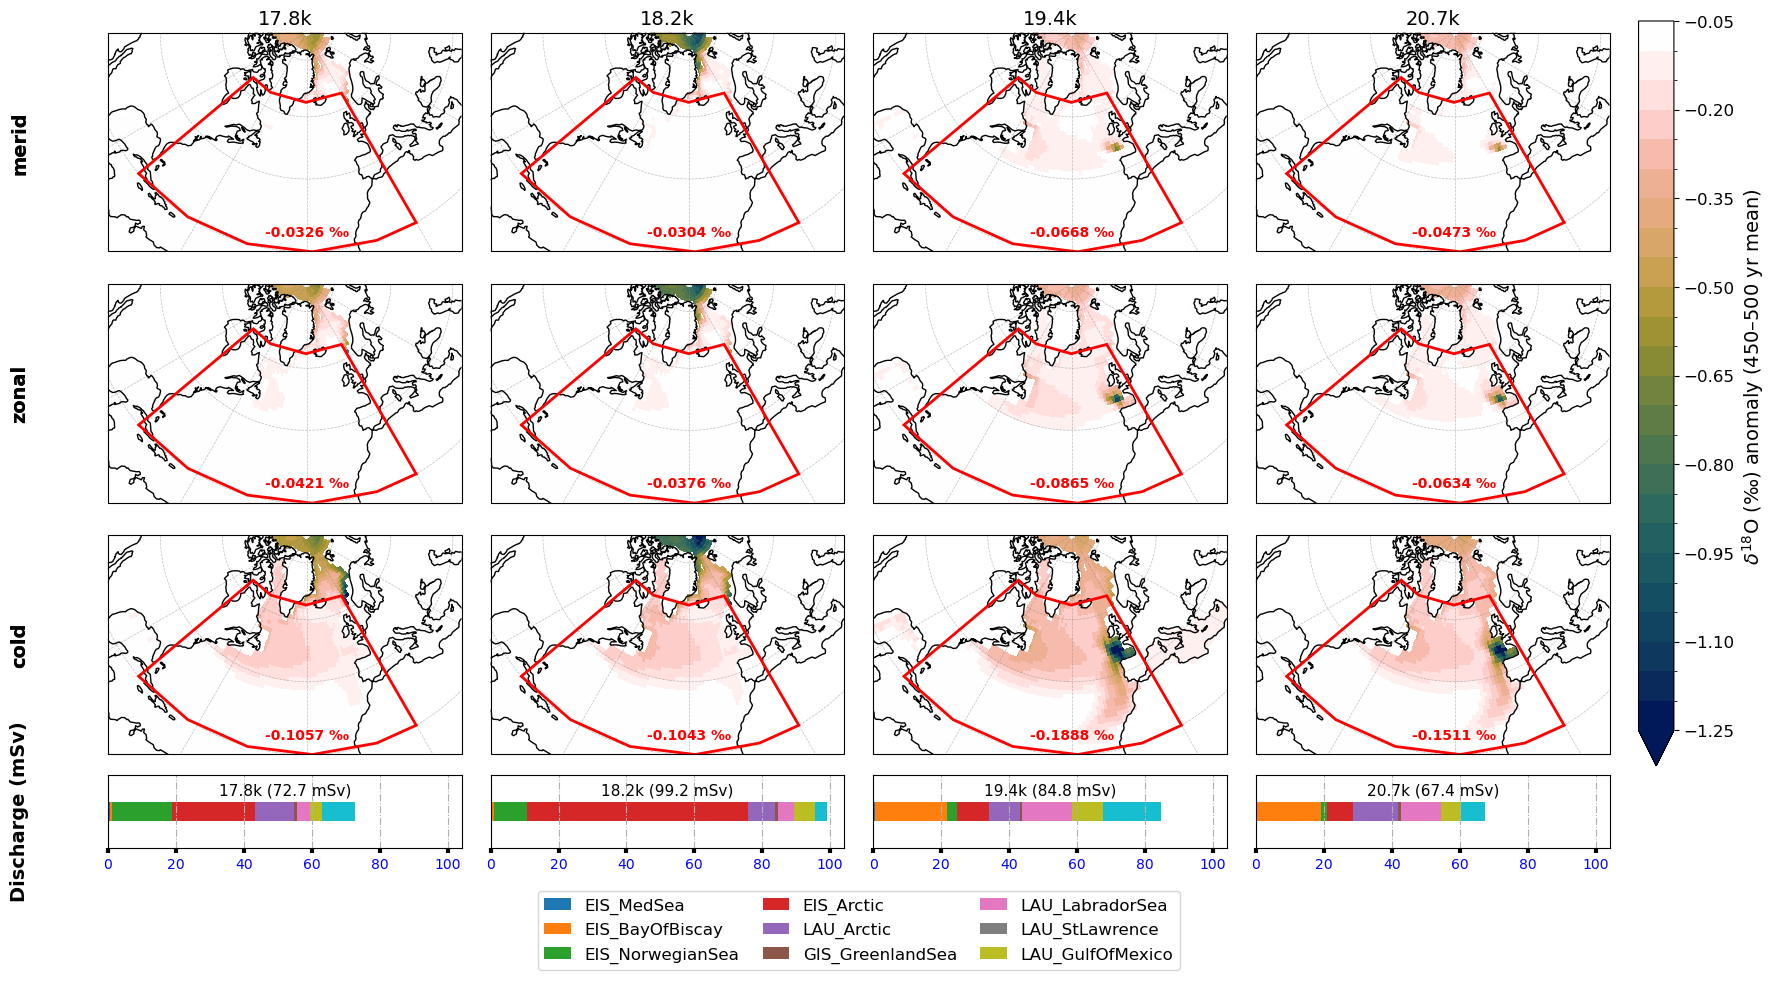

In [39]:
# 2. Predicted
from myconfig.EXPERIMENTS_prediction import EXPERIMENTS_prediction

#Libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
from matplotlib.patches import Patch

import matplotlib.patches as mpatches
from matplotlib import colors

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap
import matplotlib as mpl
import matplotlib.path as mpath
import matplotlib.patches as mpatches
from scipy.ndimage import gaussian_filter



# Boundary Boxes
lon_dis, lat_dis = ds_dyeregion.longitude.values, ds_dyeregion.latitude.values
lon_dis_b, lat_dis_b = tb.create_coordinate_edges(lon_dis), tb.create_coordinate_edges(lat_dis)


# -----------------------------
# CONFIGURATION
# -----------------------------
modes = ["merid", "zonal", "cold"]
scenarios = ["17.8k", "18.2k", "19.4k", "20.7k"]

scale_Sv_to_mSv = 1000

region_names = list(lookup_dis["17.8k"].keys())

# -----------------------------
# FIGURE + GRID
# -----------------------------

projection_map = ccrs.NorthPolarStereo(central_longitude=-30)
#projection_map = ccrs.PlateCarree(central_longitude=-30)

#axMap = axMap.flatten()
normdye = colors.Normalize(vmin=0,vmax=0.05)
normd18O = colors.Normalize(vmin=0,vmax=-1.)
normdyediff = colors.TwoSlopeNorm(vmin=-0.05, vcenter=0., vmax=0.05)

# --- Discrete colormap ---
bounds = np.arange(-1.25, 0, 0.05)
normdye18O_a = mpl.colors.BoundaryNorm(boundaries=bounds, ncolors=cmc.batlowW.N)



fig = plt.figure(figsize=(18, 11))

gs = gridspec.GridSpec(
    nrows=5,
    ncols=5,
    figure=fig,
    width_ratios=[1, 1, 1, 1, 0.1],
    height_ratios=[1, 1, 1, 0.3,0.5],
    wspace=0.1,
    hspace=0.05,
)

# map axes
axMap = np.empty((3, 4), dtype=object)
axBar = np.empty((1,4), dtype=object)
axBarLegend = np.empty((1,5), dtype=object)


for i, mode in enumerate(modes):
    for j, scen in enumerate(scenarios):
        axMap[i, j] = fig.add_subplot(
            gs[i, j],
            projection=projection_map
        )

bar_axes = [
    fig.add_subplot(gs[3, j])
    for j in range(4)
]




# colorbar axis
cax = fig.add_subplot(gs[:3, 4])


# legend
legend_ax = fig.add_subplot(gs[4,:4])
legend_ax.axis("off")

# bar axis (bottom panel already part of same figure)
# ------------------------------------------------------------------
# Bottom section: nested GridSpec
# ------------------------------------------------------------------


# -----------------------------
# MAP PLOTTING
# -----------------------------
im = None

for i, mode in enumerate(modes):
    for j, scen in enumerate(scenarios):

        ax = axMap[i, j]
        ax.grid(True)

        if scen not in EXPERIMENTS_prediction[mode]:
            ax.set_xticks([])
            ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_visible(False)
    
            ax.text(
                0.5, 0.5,
                "Not simulated",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=11,
                color="0.5",
            )
            continue

        exp = scen + "_d18O_mean"

        if exp not in d18O_results_predict[mode]:
            ax.set_xticks([])
            ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_visible(False)
    
            ax.text(
                0.5, 0.5,
                "Not simulated",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=11,
                color="0.5",
            )
            continue

        field = d18O_results_predict[mode][exp]

        avg_val = mean_predict_lookup[mode][scen]

        im = ax.pcolormesh(
            lon_dis_b,
            lat_dis_b,
            field,
            transform=ccrs.PlateCarree(),
            cmap=cmc.batlowW,
            norm=normdye18O_a,
            shading="nearest",
        )

        # gridlines
        gl = ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=False,
            linewidth=0.5,
            color="gray",
            alpha=0.5,
            linestyle="--",
        )

        # add red rectangle
        width = lon_max - lon_min
        height = lat_max - lat_min
        rect = mpatches.Rectangle(
            (lon_min, lat_min), width, height,
            linewidth=2, edgecolor='red', facecolor='none',
            transform=ccrs.PlateCarree(), zorder=50
        )
        axMap[i,j].add_patch(rect)

        # --- add average value inside the rectangle (bottom-right corner) ---
        axMap[i,j].text(
            -30, 25, f"{avg_val:.4f} ‰",  # place at bottom-right of rectangle
            color='red', fontsize=10, fontweight='bold',
            ha='center', va='center',
            transform=ccrs.PlateCarree(),
            zorder=60
        )


        ax.coastlines(zorder=10)
        ax.set_extent([-95, 15, 20, 90], crs=ccrs.PlateCarree())

# -----------------------------
# COLUMN TITLES
# -----------------------------
for j, scen in enumerate(scenarios):
    axMap[0, j].set_title(scen, fontsize=14, loc="center")

# -----------------------------
# ROW LABELS
# -----------------------------
for i, mode in enumerate(modes):
    axMap[i, 0].text(
        -0.25, 0.5,
        mode,
        rotation=90,
        transform=axMap[i, 0].transAxes,
        va="center",
        ha="center",
        fontsize=14,
        fontweight="bold",
    )


#for i, mode in enumerate(modes):

# -----------------------------
# COLUMN TITLES
# -----------------------------
for j, scen in enumerate(scenarios):
    axMap[0, j].set_title(scen, fontsize=14, loc="center")

# -----------------------------
# ROW LABELS
# -----------------------------
for i, mode in enumerate(modes):
    axMap[i, 0].text(
        -0.25, 0.5,
        mode,
        rotation=90,
        transform=axMap[i, 0].transAxes,
        va="center",
        ha="center",
        fontsize=14,
        fontweight="bold",
    )

# -----------------------------
# COLORBAR
# -----------------------------
cb = fig.colorbar(im, cax=cax, orientation="vertical", extend='min',shrink=0.6)
cb.set_label(r"$\delta^{18}$O (‰) anomaly (450–500 yr mean)",fontsize=14)
cb.ax.tick_params(labelsize=12)


# -----------------------------
# STACKED BAR PLOT (BOTTOM)
# -----------------------------


scenario_totals = {}

for scen in scenarios:
    total = sum(
        lookup_dis[scen].get(region, 0.0)
        for region in region_names
    )
    scenario_totals[scen] = total * scale_Sv_to_mSv

# colors for consistency
colors = plt.cm.tab10(np.linspace(0, 1, len(region_names)))
dye_colors = {'dye00':'tab:blue', 'dye01':'tab:orange', 'dye02':'tab:green', 'dye03':'tab:red', 'dye04':'tab:purple', 'dye05':'tab:brown', 'dye06':'tab:pink',
         'dye07':'tab:olive', 'dye08':'tab:cyan'}

# -------------------------------------------------
# STACKED BAR PLOTS
# -------------------------------------------------
region_names = list(lookup_dis["17.8k"].keys())
colors = plt.cm.tab10(np.arange(len(region_names)))

scenario_totals = {}

for scen in scenarios:
    scenario_totals[scen] = (
        sum(lookup_dis[scen].get(r, 0.0) for r in region_names)
        * scale_Sv_to_mSv
    )

xmax = max(scenario_totals.values()) * 1.05

for j, scen in enumerate(scenarios):

    ax = bar_axes[j]

    pos = ax.get_position()

    ax.set_position([
        pos.x0+0.2,
        pos.y0 + 0.5,      # shift upward
        pos.width,
        pos.height   # make slightly shorter
    ])


    left = 0

    for i, region in enumerate(region_names):

        value = lookup_dis[scen].get(region, 0.0) * scale_Sv_to_mSv

        ax.barh(
            0,
            value,
            left=left,
            color=dye_colors[f'dye0{i}'],
        )

        left += value

    ax.set_xlim(0, xmax)
    ax.set_ylim(-1.5, 1.5)

    ax.set_title(
        f"{scen} ({scenario_totals[scen]:.1f} mSv)",
        fontsize=11,
        y=1.0, pad=-14,
        
    )

    ax.set_yticks([])
    ax.grid(True, linestyle='-.')
    ax.tick_params(labelcolor='b', labelsize='medium', width=3)

    ax.set_xlabel("")

    #for spine in ["top", "right", "left"]:
    #    ax.spines[spine].set_visible(False)


bar_axes[0].text(
        -0.25, 0.5,
        'Discharge (mSv)',
        rotation=90,
        transform=bar_axes[0].transAxes,
        va="center",
        ha="center",
        fontsize=14,
        fontweight="bold",
    )


# -------------------------------------------------
# LEGEND
# -------------------------------------------------
legend_handles = [
    Patch(
        facecolor=colors[i],
        label=DYE_TABLE.iloc[i]["region"]
    )
    for i in range(len(DYE_TABLE))
]

legend_ax.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=True,
    fontsize=12,
    columnspacing=1.4,
    handlelength=1.6,
)

# -----------------------------
# FINAL LAYOUT
# -----------------------------
plt.subplots_adjust(
    left=0.05,
    right=0.92,
    top=0.95,
    bottom=0.08,
)

# Save the Figure
plt.savefig(
    "my_output/chapter-four_latestfigures/Fig5_Rev_ScenarioMap_predict.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)




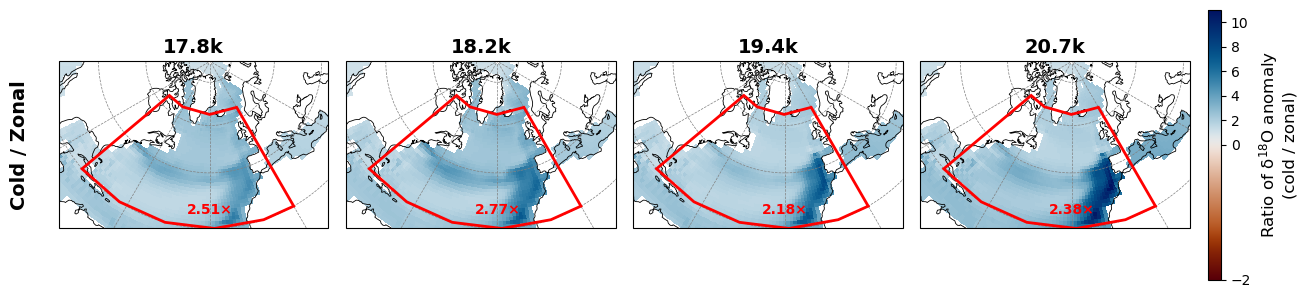

In [58]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import matplotlib.patches as mpatches
import matplotlib as mpl


# -----------------------------
# CONFIGURATION
# -----------------------------
modes = ["merid", "zonal", "cold"]
scenarios = ["17.8k", "18.2k", "19.4k", "20.7k"]

scale_Sv_to_mSv = 1000

region_names = list(lookup_dis["17.8k"].keys())


# --------------------------------------------------
# Figure
# --------------------------------------------------

projection = ccrs.NorthPolarStereo(central_longitude=-30)

fig = plt.figure(figsize=(15,3.5))

gs = gridspec.GridSpec(
    1,
    5,
    width_ratios=[1,1,1,1,0.05],
    wspace=0.08,
)

axes = [
    fig.add_subplot(gs[0,i], projection=projection)
    for i in range(4)
]

cax = fig.add_subplot(gs[0,4])

# --------------------------------------------------
# Ratio colour scale
# --------------------------------------------------

norm = mpl.colors.TwoSlopeNorm(
    vmin=-2.,
    vcenter=0,
    vmax=11.0,
)

#cmap = "RdBu_r"
cmap = cmc.vik_r


# --------------------------------------------------
# Plot
# --------------------------------------------------

im = None

for j, scen in enumerate(scenarios):

    ax = axes[j]

    if scen not in EXPERIMENTS_prediction["cold"]:
        ax.axis("off")
        continue

    field_cold = d18O_results_predict["cold"][f"{scen}_d18O_mean"]
    field_zonal = d18O_results_predict["zonal"][f"{scen}_d18O_mean"]

    ratio = field_cold / field_zonal

    # avoid division by very small values
    ratio = ratio.where(abs(field_zonal) > 1e-6)

    # max?
    #print("max",ratio.max().values)

    im = ax.pcolormesh(
        lon_dis_b,
        lat_dis_b,
        ratio,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        shading="nearest",
    )

    ax.coastlines(linewidth=0.6)

    ax.gridlines(
        draw_labels=False,
        linewidth=0.5,
        linestyle="--",
        color="0.5",
    )

    ax.set_extent([-95,15,20,90], crs=ccrs.PlateCarree())

    # same comparison box
    rect = mpatches.Rectangle(
        (lon_min, lat_min),
        lon_max-lon_min,
        lat_max-lat_min,
        transform=ccrs.PlateCarree(),
        facecolor="none",
        edgecolor="red",
        linewidth=2,
        zorder=20,
    )

    ax.add_patch(rect)

    # regional mean ratio
    mean_ratio = (
        mean_predict_lookup["cold"][scen]
        / mean_predict_lookup["zonal"][scen]
    )

    ax.text(
        -30,
        25,
        f"{mean_ratio:.2f}×",
        color="red",
        fontsize=10,
        weight="bold",
        transform=ccrs.PlateCarree(),
        ha="center",
    )

    ax.set_title(
        scen,
        fontsize=14,
        weight="bold",
    )

# --------------------------------------------------
# Row label
# --------------------------------------------------

axes[0].text(
    -0.18,
    0.5,
    "Cold / Zonal",
    rotation=90,
    transform=axes[0].transAxes,
    fontsize=14,
    weight="bold",
    va="center",
)

# --------------------------------------------------
# Colorbar
# --------------------------------------------------

cb = fig.colorbar(
    im,
    cax=cax,
)

cb.set_label(
    "Ratio of δ$^{18}$O anomaly\n(cold / zonal)",
    fontsize=12,
)

#plt.show()


# Save the Figure
plt.savefig(
    "my_output/chapter-four_latestfigures/Fig5_Rev_Ratio.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=300,
)


In [56]:
ratio.max().values

array(5.6523476, dtype=float32)

In [22]:
#### Legacy Old Computation, and predicted on the mean!

# Plot for Each AMOC mode Anomaly Field
### aft450-500 years of injection. how does the total surface map look for the for scenarios for AMOC modes?

# Boundary Boxes
lon_dis, lat_dis = ds_dyeregion.longitude.values, ds_dyeregion.latitude.values
lon_dis_b, lat_dis_b = tb.create_coordinate_edges(lon_dis), tb.create_coordinate_edges(lat_dis)


land_sites_name = ["NISA","NGRIP","Puerto","NoName"]
land_sites_lon = [360-4.8,360-42.3167,360-66.8,360-98.63]
land_sites_lat = [43.41,75.1,18.32,29.87]

#ocean_sites_name = ["GIN","BOB","BER"]
ocean_sites_lon = [360-4.5667,360-21.7667,360-48.6,360-14.7,360-10.1667,360-91.345300]
ocean_sites_lat = [66.6833, 67.8667, 57.4333, 55.4833, 37.8, 26.946700]

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap
import matplotlib as mpl
import matplotlib.path as mpath
import matplotlib.patches as mpatches
from scipy.ndimage import gaussian_filter
from mymodules.d18O_computation import area_weighted_mean

# scenarios
exp_n = ["17.8k", "18.2k", "19.4k", "20.7k"]
exp_list = ["xpral", "xpujm", "xpujj", "xpujg"]

import matplotlib.patches as mpatches
from matplotlib import colors

plt.rcParams.update({
    "figure.figsize": (12, 8),        # bigger figure
    "figure.dpi": 150,                # high resolution
    "axes.titlesize": 16,             # title font
    "axes.labelsize": 20,             # axis label font
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
    "lines.linewidth": 3,             # thicker lines
    "lines.markersize": 8,
    "font.family": "sans-serif",
})

#projection_map = ccrs.NearsidePerspective(central_longitude=-35, central_latitude=45, satellite_height=11000000)
# Define the Lambert Azimuthal Equal-Area projection centered on the Northern Hemisphere
#projection_map = ccrs.LambertAzimuthalEqualArea(central_longitude=-40, central_latitude=60)

#projection_map = ccrs.PlateCarree()
projection_map = ccrs.NorthPolarStereo(central_longitude=-30)

#Def
figMap,(axMap) = plt.subplots(nrows=3, ncols=4, subplot_kw={'projection':projection_map}, figsize=(18,14))
#axMap = axMap.flatten()
normdye = colors.Normalize(vmin=0,vmax=0.05)
normd18O = colors.Normalize(vmin=0,vmax=-1.)
normdyediff = colors.TwoSlopeNorm(vmin=-0.05, vcenter=0., vmax=0.05)

# --- Discrete colormap ---
bounds = np.arange(-1.25, 0, 0.05)
normdye18O_a = mpl.colors.BoundaryNorm(boundaries=bounds, ncolors=cmc.batlowW.N)


#The four snapshots
for j in range(4):#4
    for i,mode in enumerate(['cold','zonal','merid']):
        # Set the extent to focus on the Northern Hemisphere including Iberia and Gulf of Mexico
        axMap[i,j].set_extent([-95, 15, 20, 90], crs=ccrs.PlateCarree())
        axMap[i,j].coastlines(zorder=10)
        #axMap[i,j].pcolormesh(lsm.longitude, lsm.latitude,xr.where(lsm==0, np.nan,lsm),
        #              #cmap=ListedColormap(['xkcd:pale brown']), 
        #              cmap=ListedColormap(['#cccccc']),
        #              #cmap=ListedColormap(['#EEEEEE']),         
        #              transform=ccrs.PlateCarree(),
        #              shading="nearest",
        #              zorder=1)




        
        cmap = axMap[i,j].pcolormesh(lon_dis_b, lat_dis_b,
                                     dict_dye[mode][f'{gdf_list[j]} total d18O'],#.rolling(lat=3, lon=3, center=True).mean(), 
                                     transform=ccrs.PlateCarree(), 
                        norm=normdye18O_a, shading="nearest",
                        cmap=cmc.batlowW, alpha=1)
        
    
        #axMap[i,j].set_title(f'{gdf_list[j]}',loc='left',fontsize=24)
        # experiment label box
        axMap[i,j].set_title(f"{exp_n[j]}_{mode}", loc="left", fontstyle="italic")
        


        # add red rectangle
        width = lon_max - lon_min
        height = lat_max - lat_min
        rect = mpatches.Rectangle(
            (lon_min, lat_min), width, height,
            linewidth=2, edgecolor='red', facecolor='none',
            transform=ccrs.PlateCarree(), zorder=50
        )
        axMap[i,j].add_patch(rect)

        # --- add average value inside the rectangle (bottom-right corner) ---
        avg_val = dict_dye[mode][f'{gdf_list[j]} total d18O mean NA']  # your variable
        axMap[i,j].text(
            -30, 25, f"{avg_val:.4f} ‰",  # place at bottom-right of rectangle
            color='red', fontsize=10, fontweight='bold',
            ha='center', va='center',
            transform=ccrs.PlateCarree(),
            zorder=60
        )


        # --- inside your plotting loop, after axMap[i,j].pcolormesh(...) ---

        # plot land sites (stars)
        #axMap[i,j].scatter(
        #    land_sites_lon, land_sites_lat,
        #    transform=ccrs.PlateCarree(),
        #    marker="*", c="gold", s=120, edgecolor="black", zorder=100,
        #    label="Land sites" if (i == 0 and j == 0) else None
        #)
    
        
        # plot ocean sites (circles)
        #axMap[i,j].scatter(
        #    ocean_sites_lon, ocean_sites_lat,
        #    transform=ccrs.PlateCarree(),
        #    marker="o", c="dodgerblue", s=50, edgecolor="black", zorder=90,
        #    label="Ocean sites" if (i == 0 and j == 0) else None
        #)
    
        # add legend only once (top-left subplot)
        #if i == 0 and j == 0:
         #   axMap[i,j].legend(loc="lower left", fontsize=10, frameon=True)

cb = plt.colorbar(cmap,ax=axMap, shrink=0.8,location="bottom",extend='min')
cb.set_label(f"30yr-mean d18O dye anomaly after \n450-500 years injection", size=16)
cb.ax.tick_params(labelsize=16)

# --- Adjust spacing ---
plt.subplots_adjust(wspace=0.02, hspace=0.08, bottom=0.25)


#plt.tight_layout()
#plt.savefig(f'scenarios_d18O_maps.png',dpi=300,transparent=False)



ImportError: cannot import name 'area_weighted_mean' from 'mymodules.d18O_computation' (/nfs/mary/Users/zgcq387/scripts/jupyter/mymodules/d18O_computation.py)

# Fig 4
1. Define the Regions
2. compute the regional mean values
3. single GIN-NISA plot, from simulation
4. single GIN-NISA plot, from prediction
5. full scatter and map, from simulation
6. full scatter and map, from prediction

In [26]:
# ---------------------------
# Define the regions
# ---------------------------

regions = {
        "Arctic": dict(lat_min=85, lat_max=90, lon_min=-170, lon_max=170),
        "GIN":    dict(lat_min=67, lat_max=73, lon_min=-8, lon_max=5), # Centered on Norwegian Seas now, based on MLD in the model?
        "IRD belt":    dict(lat_min=40, lat_max=48, lon_min=360-45, lon_max=360-15), # kind of a Ruddiman-like region?
        #"IRD belt":    dict(lat_min=40, lat_max=55, lon_min=360-30, lon_max=360-10), # slope is very sensitive to change of the region!

    }




In [27]:
comp_lookup = {}
comp_lookup_old = {}

comp_lookup_min = {}
comp_lookup_min_old = {}
comp_lookup_max = {}
comp_lookup_max_old = {}

for reg, coords in regions.items():

    comp_lookup[reg], comp_lookup_old[reg] = build_d18O_mean_lookup(
        experiments=EXPERIMENTS,
        d18O_results=d18O_results,
        lon_min=coords["lon_min"],
        lon_max=coords["lon_max"],
        lat_min=coords["lat_min"],
        lat_max=coords["lat_max"],
        lsm=lsm,
    )  

    #min
    comp_lookup_min[reg], comp_lookup_min_old[reg] = build_d18O_mean_lookup(
        experiments=EXPERIMENTS,
        d18O_results=d18O_results_min,
        lon_min=coords["lon_min"],
        lon_max=coords["lon_max"],
        lat_min=coords["lat_min"],
        lat_max=coords["lat_max"],
        lsm=lsm,
    )    

    #min
    comp_lookup_max[reg], comp_lookup_max_old[reg] = build_d18O_mean_lookup(
        experiments=EXPERIMENTS,
        d18O_results=d18O_results_max,
        lon_min=coords["lon_min"],
        lon_max=coords["lon_max"],
        lat_min=coords["lat_min"],
        lat_max=coords["lat_max"],
        lsm=lsm,
    )    




comp_predict_lookup = {}
comp_predict_lookup_old = {}

for reg, coords in regions.items():

    comp_predict_lookup[reg], comp_predict_lookup_old[reg] = build_d18O_mean_lookup(
        experiments=EXPERIMENTS_prediction,
        d18O_results=d18O_results_predict,
        lon_min=coords["lon_min"],
        lon_max=coords["lon_max"],
        lat_min=coords["lat_min"],
        lat_max=coords["lat_max"],
        
    )    






modes: 100%|██████████████████████████████████████| 3/3 [00:00<00:00, 35.31it/s]


Using experiment format for xpraj
Using experiment format for xpujl
Using experiment format for xpuji
Using experiment format for xpujf
Using experiment format for xpral
Looking for 18.2k_d18O_mean
Not found!
Using experiment format for xpujj
Using experiment format for xpujg
Using experiment format for xprak
Using experiment format for xpujk
Using experiment format for xpujh


modes:   0%|                                              | 0/3 [00:00<?, ?it/s]

Using experiment format for xpraj
Using experiment format for xpujl
Using experiment format for xpuji
Using experiment format for xpujf


modes:  33%|████████████▋                         | 1/3 [00:00<00:01,  1.15it/s]

...

Looking for 18.2k_d18O_mean
Found prediction
Looking for 19.4k_d18O_mean
Found prediction
Looking for 20.7k_d18O_mean
Found prediction
Looking for 17.8k_d18O_mean
Found prediction
Looking for 18.2k_d18O_mean
Found prediction
Looking for 19.4k_d18O_mean
Found prediction
Looking for 20.7k_d18O_mean
Found prediction


modes: 100%|██████████████████████████████████████| 3/3 [00:00<00:00, 45.01it/s]


Looking for 17.8k_d18O_mean
Found prediction
Looking for 18.2k_d18O_mean
Found prediction
Looking for 19.4k_d18O_mean
Found prediction
Looking for 20.7k_d18O_mean
Found prediction
Looking for 17.8k_d18O_mean
Found prediction
Looking for 18.2k_d18O_mean
Found prediction
Looking for 19.4k_d18O_mean
Found prediction
Looking for 20.7k_d18O_mean
Found prediction
Looking for 17.8k_d18O_mean
Found prediction
Looking for 18.2k_d18O_mean
Found prediction
Looking for 19.4k_d18O_mean
Found prediction
Looking for 20.7k_d18O_mean
Found prediction


modes: 100%|██████████████████████████████████████| 3/3 [00:00<00:00, 74.65it/s]

Looking for 17.8k_d18O_mean
Found prediction
Looking for 18.2k_d18O_mean
Found prediction
Looking for 19.4k_d18O_mean
Found prediction
Looking for 20.7k_d18O_mean
Found prediction
Looking for 17.8k_d18O_mean
Found prediction
Looking for 18.2k_d18O_mean
Found prediction
Looking for 19.4k_d18O_mean
Found prediction
Looking for 20.7k_d18O_mean
Found prediction
Looking for 17.8k_d18O_mean
Found prediction
Looking for 18.2k_d18O_mean
Found prediction
Looking for 19.4k_d18O_mean
Found prediction
Looking for 20.7k_d18O_mean
Found prediction


In [28]:
import numpy as np
from scipy.stats import linregress


def slope_through_origin(x, y):
    """
    Linear regression forced through zero.

    Returns slope and correlation coefficient.
    """

    x = np.asarray(x)
    y = np.asarray(y)

    # slope for y = m*x
    slope = np.sum(x*y) / np.sum(x*x)

    # correlation coefficient
    r = np.corrcoef(x, y)[0,1]

    return slope, r

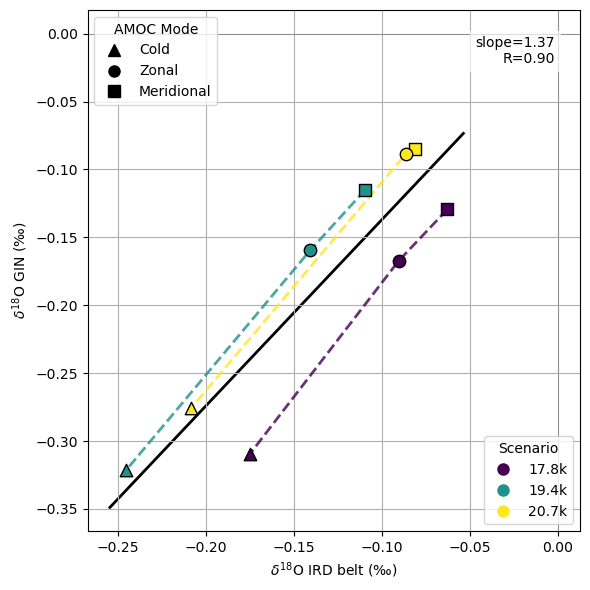

In [28]:
# 1) simulated
from matplotlib.lines import Line2D
from matplotlib.patches import Patch



# Preset data: snapshot list, states, and site data dictionaries
snapshots = ['17.8k', '19.4k', '20.7k']
states = ['merid','zonal','cold']
colors = plt.cm.viridis(np.linspace(0, 1, len(snapshots)))


# Define snapshot colors
snapshot_colors = {
    '17.8k': 'tab:blue',
    '18.2k': 'tab:orange',
    '19.4k': 'tab:green',
    '20.7k': 'tab:red'
}

# Define markers per state
state_markers = {
    'cold': '^',   # triangle
    'zonal': 'o',   # circle
    'merid': 's'
}



# Replace with your actual DataFrames
state = 'cold'
sites = {
    'GIN': comp_lookup['GIN'][state].values(),     # These should be DataFrames indexed by state and columns = dye regions
    'IRD belt': comp_lookup['IRD belt'][state].values()
}

# Prepare plot
fig, ax = plt.subplots(figsize=(6, 6))


x_all = []
y_all = []

# Loop over snapshots
for i, snap in enumerate(snapshots):
    color = colors[i]

    xvals = []
    yvals = []

    # ----------------------------------
    # connect the three AMOC states
    # ----------------------------------
    
    
    for state in states:
        # Construct column name
        col_name = f'{snap} - {state}'

        x = comp_lookup["IRD belt"][state][snap]
        y = comp_lookup["GIN"][state][snap]

        xvals.append(x)
        yvals.append(y)

        x_all.append(x)
        y_all.append(y)

        # Sum over all dye contributions for this snapshot/state

        # Choose marker based on state
        marker = state_markers[state]
        fillstyle = 'full' if state == 'cold' else 'none'

        ax.scatter(x,y, color=color, marker=marker, s=80,
                   label=f'{snap} - {state}' if state == 'cold' else None,
                   edgecolor='black',zorder=3)

    ax.plot(
            xvals,yvals,
            color=color,
            linewidth=2,
            alpha=0.8,
            zorder=2,
            linestyle="--",
        )


# -----------------------------
# overall scaling relationship
# -----------------------------

slope, r = slope_through_origin(
    x_all,
    y_all
)


# plot slope line
xmin,xmax=ax.get_xlim()

xx=np.linspace(xmin,xmax,100)

ax.plot(
    xx,
    slope*xx,
    color="black",
    linewidth=2,
    linestyle="-",
    zorder=1,
)


# annotate
ax.text(
    0.95,
    0.95,
    f"slope={slope:.2f}\nR={r:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(
        facecolor="white",
        alpha=0.7,
        edgecolor="none"
    )
)



# Formatting
ax.set_xlabel(
        rf"$\delta^{{18}}$O IRD belt (‰)"
    )

ax.set_ylabel(
        rf"$\delta^{{18}}$O GIN (‰)"
    )
#ax.set_title("Sum of Source Contributions: NISA vs GIN")
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.grid(True)

# Custom legend
handles = [
    plt.Line2D([0], [0], marker='^', color='k', label='Cold', linestyle='None', markersize=8),
    plt.Line2D([0], [0], marker='o', color='k', label='Zonal', linestyle='None', markersize=8),
    plt.Line2D([0], [0], marker='s', color='k', label='Meridional', linestyle='None', markersize=8),

]
snapshot_handles = [
    plt.Line2D([0], [0], marker='o', color=colors[i], label=snapshots[i], linestyle='None', markersize=8)
    for i in range(len(snapshots))
]

legend1 = ax.legend(handles=handles, loc='upper left', title="AMOC Mode")
legend2 = ax.legend(handles=snapshot_handles, loc='lower right', title="Scenario")
ax.add_artist(legend1)

plt.tight_layout()
#plt.show()

plt.savefig("my_output/chapter-four_latestfigures/Fig4_Rev_GIN_IRD.pdf")

In [33]:
comp_lookup_max["IRD belt"][state][snap]

-0.23831578926984215

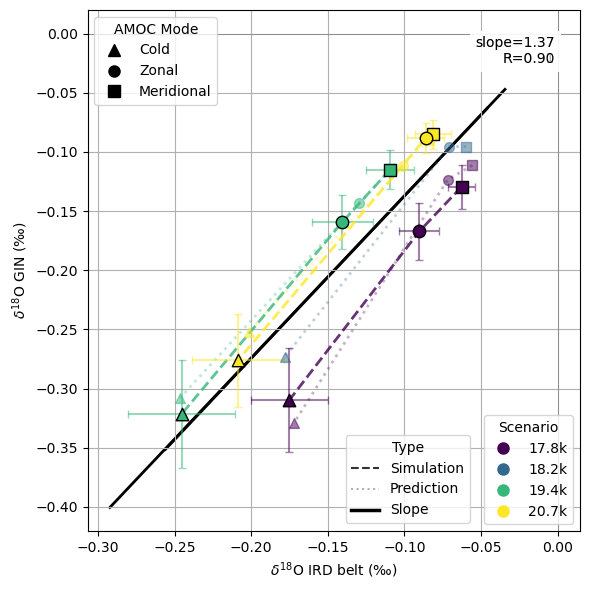

In [36]:
#2)Predicted
from matplotlib.lines import Line2D
from matplotlib.patches import Patch



# Preset data: snapshot list, states, and site data dictionaries
snapshots = ['17.8k', '18.2k','19.4k', '20.7k']
states = ['merid','zonal','cold']
colors = plt.cm.viridis(np.linspace(0, 1, len(snapshots)))


# Define snapshot colors
snapshot_colors = {
    '17.8k': 'tab:blue',
    '18.2k': 'tab:orange',
    '19.4k': 'tab:green',
    '20.7k': 'tab:red'
}

# Define markers per state
state_markers = {
    'cold': '^',   # triangle
    'zonal': 'o',   # circle
    'merid': 's'
}



# Replace with your actual DataFrames
#sites_predicted = {
#    'GIN': comp_predict_lookup['GIN'][state].values(),     # These should be DataFrames indexed by state and columns = dye regions
#    'IRD belt': comp_predict_lookup['IRD belt'][state].values()
#}

# Prepare plot
fig, ax = plt.subplots(figsize=(6, 6))


x_all = []
y_all = []

# Loop over snapshots
for i, snap in enumerate(snapshots):
    color = colors[i]

    xvals = []
    yvals = []

    # ----------------------------------
    # connect the three AMOC states
    # ----------------------------------
    
    
    for state in states:
        # Construct column name
        col_name = f'{snap} - {state}'

        x = comp_predict_lookup["IRD belt"][state][snap]
        y = comp_predict_lookup["GIN"][state][snap]

        xvals.append(x)
        yvals.append(y)

        x_all.append(x)
        y_all.append(y)

        # Sum over all dye contributions for this snapshot/state

        # Choose marker based on state
        marker = state_markers[state]
        fillstyle = 'full' if state == 'cold' else 'none'

        ax.scatter(x,y, color=color, marker=marker, s=50,
                   label=f'{snap} - {state}' if state == 'cold' else None,
                   #edgecolor='black',
                   zorder=3,alpha=0.5,)

    ax.plot(
            xvals,yvals,
            color=color,
            linewidth=2,
            alpha=0.3,
            zorder=2,
            linestyle=":",
        )





# -----------------------------
# overall scaling relationship
# -----------------------------

slope, r = slope_through_origin(
    x_all,
    y_all
)


# plot slope line
xmin,xmax=ax.get_xlim()

xx=np.linspace(xmin,xmax,100)

ax.plot(
    xx,
    slope*xx,
    color="black",
    linewidth=2,
    linestyle="-",
    zorder=1,
)


# annotate
ax.text(
    0.95,
    0.95,
    f"slope={slope:.2f}\nR={r:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(
        facecolor="white",
        alpha=0.7,
        edgecolor="none"
    )
)


#### SAME FOR SIMULATED

# Preset data: snapshot list, states, and site data dictionaries
snapshots = ['17.8k', '19.4k', '20.7k']
states = ['merid','zonal','cold']
#colors = plt.cm.viridis(np.linspace(0, 1, len(snapshots)))

colors2 = np.delete(colors, 1, axis=0)


# Define snapshot colors
snapshot_colors = {
    '17.8k': 'tab:blue',
    '18.2k': 'tab:orange',
    '19.4k': 'tab:green',
    '20.7k': 'tab:red'
}

# Define markers per state
state_markers = {
    'cold': '^',   # triangle
    'zonal': 'o',   # circle
    'merid': 's'
}



# Replace with your actual DataFrames
state = 'cold'
sites = {
    'GIN': comp_lookup['GIN'][state].values(),     # These should be DataFrames indexed by state and columns = dye regions
    'IRD belt': comp_lookup['IRD belt'][state].values()
}

# Prepare plot
#fig, ax = plt.subplots(figsize=(6, 6))


x_all = []
y_all = []

# Loop over snapshots
for i, snap in enumerate(snapshots):
    color = colors2[i]

    xvals = []
    yvals = []

    # ----------------------------------
    # connect the three AMOC states
    # ----------------------------------
    
    
    for state in states:
        # Construct column name
        col_name = f'{snap} - {state}'

        #x = comp_lookup["IRD belt"][state][snap]
        #y = comp_lookup["GIN"][state][snap]


        x      = comp_lookup["IRD belt"][state][snap]
        x_min  = comp_lookup_min["IRD belt"][state][snap]
        x_max  = comp_lookup_max["IRD belt"][state][snap]
        
        y      = comp_lookup["GIN"][state][snap]
        y_min  = comp_lookup_min["GIN"][state][snap]
        y_max  = comp_lookup_max["GIN"][state][snap]

        # asymmetric errors
        xerr = [[x - x_max],      # left error
                [x_min - x]]      # right error
        
        yerr = [[y - y_max],      # lower error
                [y_min - y]]      # upper error
                

        xvals.append(x)
        yvals.append(y)

        x_all.append(x)
        y_all.append(y)

        # Sum over all dye contributions for this snapshot/state

        # Choose marker based on state
        marker = state_markers[state]
        fillstyle = 'full' if state == 'cold' else 'none'

        ax.errorbar(
            x,
            y,
            xerr=xerr,
            yerr=yerr,
            fmt="none",          # don't draw marker
            ecolor=color,
            elinewidth=1.5,
            capsize=3,
            alpha=0.5,
            zorder=2,
        )

        ax.scatter(x,y, color=color, marker=marker, s=80,
                   label=f'{snap} - {state}' if state == 'cold' else None,
                   edgecolor='black',zorder=3)

    ax.plot(
            xvals,yvals,
            color=color,
            linewidth=2,
            alpha=0.8,
            zorder=2,
            linestyle="--",
        )


# -----------------------------
# overall scaling relationship
# -----------------------------

slope, r = slope_through_origin(
    x_all,
    y_all
)


# plot slope line
xmin,xmax=ax.get_xlim()

xx=np.linspace(xmin,xmax,100)

ax.plot(
    xx,
    slope*xx,
    color="black",
    linewidth=2,
    linestyle="-",
    zorder=1,
)


# annotate
ax.text(
    0.95,
    0.95,
    f"slope={slope:.2f}\nR={r:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(
        facecolor="white",
        alpha=0.7,
        edgecolor="none"
    )
)





# Formatting
ax.set_xlabel(
        rf"$\delta^{{18}}$O IRD belt (‰)"
    )

ax.set_ylabel(
        rf"$\delta^{{18}}$O GIN (‰)"
    )
#ax.set_title("Sum of Source Contributions: NISA vs GIN")
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.grid(True)

# Custom legend
handles = [
    plt.Line2D([0], [0], marker='^', color='k', label='Cold', linestyle='None', markersize=8),
    plt.Line2D([0], [0], marker='o', color='k', label='Zonal', linestyle='None', markersize=8),
    plt.Line2D([0], [0], marker='s', color='k', label='Meridional', linestyle='None', markersize=8),

]

snapshots = ['17.8k', '18.2k','19.4k', '20.7k']
snapshot_handles = [
    plt.Line2D([0], [0], marker='o', color=colors[i], label=snapshots[i], linestyle='None', markersize=8)
    for i in range(len(snapshots))
]

line_handles = [
    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=1.5,
        alpha=0.8,
        label="Simulation"
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linestyle=":",
        linewidth=1.5,
        alpha=0.3,
        label="Prediction"
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linestyle="-",
        linewidth=2.5,
        alpha=1,
        label="Slope"
    ),
]





legend1 = ax.legend(handles=handles, loc='upper left', title="AMOC Mode")
legend2 = ax.legend(handles=snapshot_handles, loc='lower right', title="Scenario")
legend3 = ax.legend(handles=line_handles, loc="center left",
    bbox_to_anchor=(0.51, 0.1),title="Type")
ax.add_artist(legend1)
ax.add_artist(legend2)


plt.tight_layout()
#plt.show()

plt.savefig("my_output/chapter-four_latestfigures/Fig4_Rev_GIN_IRD_predict_combined.pdf")

In [77]:
comp_lookup_max


{'Arctic': {'cold': {'17.8k': -0.5907651862636065,
   '18.2k': -0.9369103343290849,
   '19.4k': -0.4292118590209355,
   '20.7k': -0.43575843988325624},
  'merid': {'17.8k': -0.4931546862946501,
   '19.4k': -0.32856636361997466,
   '20.7k': -0.319322504702425},
  'zonal': {'17.8k': -0.5546068577730525,
   '19.4k': -0.3589914912343544,
   '20.7k': -0.33004187368372623}},
 'GIN': {'cold': {'17.8k': -0.30958963958915925,
   '18.2k': -0.2535468913928005,
   '19.4k': -0.321641475642501,
   '20.7k': -0.27605030955751736},
  'merid': {'17.8k': -0.12944377020020556,
   '19.4k': -0.11505272150080677,
   '20.7k': -0.08508516145973229},
  'zonal': {'17.8k': -0.16720993806452855,
   '19.4k': -0.15930342824328955,
   '20.7k': -0.0883285970946054}},
 'IRD belt': {'cold': {'17.8k': -0.1749846399118859,
   '18.2k': -0.21887314247380402,
   '19.4k': -0.24542083940315151,
   '20.7k': -0.2085263156111118},
  'merid': {'17.8k': -0.06272122226649118,
   '19.4k': -0.1094171908437488,
   '20.7k': -0.081163790

In [78]:
comp_lookup_min

{'Arctic': {'cold': {'17.8k': -0.5907651862636065,
   '18.2k': -0.9369103343290849,
   '19.4k': -0.4292118590209355,
   '20.7k': -0.43575843988325624},
  'merid': {'17.8k': -0.4931546862946501,
   '19.4k': -0.32856636361997466,
   '20.7k': -0.319322504702425},
  'zonal': {'17.8k': -0.5546068577730525,
   '19.4k': -0.3589914912343544,
   '20.7k': -0.33004187368372623}},
 'GIN': {'cold': {'17.8k': -0.30958963958915925,
   '18.2k': -0.2535468913928005,
   '19.4k': -0.321641475642501,
   '20.7k': -0.27605030955751736},
  'merid': {'17.8k': -0.12944377020020556,
   '19.4k': -0.11505272150080677,
   '20.7k': -0.08508516145973229},
  'zonal': {'17.8k': -0.16720993806452855,
   '19.4k': -0.15930342824328955,
   '20.7k': -0.0883285970946054}},
 'IRD belt': {'cold': {'17.8k': -0.1749846399118859,
   '18.2k': -0.21887314247380402,
   '19.4k': -0.24542083940315151,
   '20.7k': -0.2085263156111118},
  'merid': {'17.8k': -0.06272122226649118,
   '19.4k': -0.1094171908437488,
   '20.7k': -0.081163790

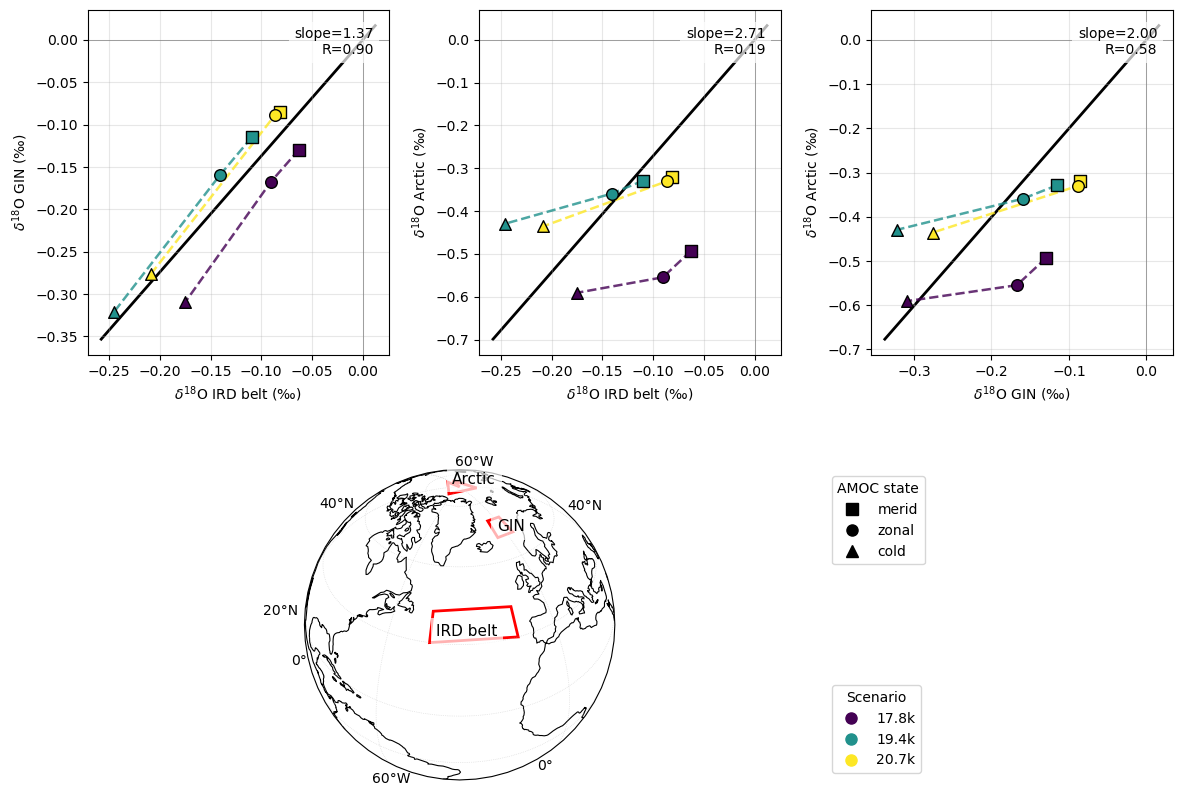

In [33]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import matplotlib.patches as mpatches


# --------------------------------------------------
# SETTINGS
# --------------------------------------------------

snapshots = ['17.8k', '19.4k', '20.7k']
states = ['merid','zonal','cold']

colors = plt.cm.viridis(np.linspace(0,1,len(snapshots)))


# region pairs for the three panels vs GIN
region_pairs = [
    ("IRD belt", "GIN"),
    ("IRD belt","Arctic"),
    ("GIN","Arctic")
]


# --------------------------------------------------
# FIGURE LAYOUT
# --------------------------------------------------

fig = plt.figure(figsize=(14,10))

gs = gridspec.GridSpec(
    nrows=2,
    ncols=3,
    height_ratios=[1,0.9],
    hspace=0.35,
    wspace=0.3
)


axes_scatter = [
    fig.add_subplot(gs[0,i])
    for i in range(3)
]


# --------------------------------------
# Bottom row: centered map + legend box
# --------------------------------------

gs_bottom = gridspec.GridSpecFromSubplotSpec(
    nrows=1,
    ncols=3,
    subplot_spec=gs[1,:],
    width_ratios=[0.01, 1, 0.5],   # empty | globe | legends
    wspace=0.05
)


# empty space left to center block
ax_empty = fig.add_subplot(gs_bottom[0])
ax_empty.axis("off")


# globe
projection_map = ccrs.NearsidePerspective(
    central_longitude=-35,
    central_latitude=45,
    satellite_height=11000000
)

ax_map = fig.add_subplot(
    gs_bottom[1],
    projection=projection_map
)


# legend container
ax_legend = fig.add_subplot(gs_bottom[2])
ax_legend.axis("off")


# --------------------------------------------------
# SCATTER PANELS
# --------------------------------------------------

for ax,(regx,regy) in zip(axes_scatter,region_pairs):

    x_all = []
    y_all = []

    for i,snap in enumerate(snapshots):

        color = colors[i]

        xvals=[]
        yvals=[]

        for state in states:

            x = comp_lookup[regx][state][snap]
            y = comp_lookup[regy][state][snap]

            xvals.append(x)
            yvals.append(y)

            x_all.append(x)
            y_all.append(y)


            ax.scatter(
                x,
                y,
                color=color,
                marker=state_markers[state],
                s=70,
                edgecolor="black",
                zorder=3
            )


        # connect AMOC states
        ax.plot(
            xvals,
            yvals,
            color=color,
            linestyle="--",
            linewidth=1.8,
            alpha=0.8
        )


    ax.axhline(0,color="grey",lw=0.5)
    ax.axvline(0,color="grey",lw=0.5)

    ax.grid(alpha=0.3)

    ax.set_xlabel(
        rf"$\delta^{{18}}$O {regx} (‰)"
    )

    ax.set_ylabel(
        rf"$\delta^{{18}}$O {regy} (‰)"
    )


    # -----------------------------
    # overall scaling relationship
    # -----------------------------
    
    slope, r = slope_through_origin(
        x_all,
        y_all
    )
    
    
    # plot slope line
    xmin,xmax=ax.get_xlim()
    
    xx=np.linspace(xmin,xmax,100)
    
    ax.plot(
        xx,
        slope*xx,
        color="black",
        linewidth=2,
        linestyle="-",
        zorder=1,
    )
    
    
    # annotate
    ax.text(
        0.95,
        0.95,
        f"slope={slope:.2f}\nR={r:.2f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(
            facecolor="white",
            alpha=0.7,
            edgecolor="none"
        )
    )




# --------------------------------------------------
# MAP PANEL
# --------------------------------------------------

#ax_map.set_extent(
#        [-100,25,20,90],
#    crs=ccrs.PlateCarree()
#)

ax_map.set_global()

ax_map.coastlines(
    linewidth=0.8
)


# region boundaries
for name,coords in regions.items():

    width = coords["lon_max"] - coords["lon_min"]
    height = coords["lat_max"] - coords["lat_min"]

    rect = mpatches.Rectangle(
        (coords["lon_min"],coords["lat_min"]),
        width,
        height,
        linewidth=2,
        edgecolor="red",
        facecolor="none",
        transform=ccrs.PlateCarree(),
        clip_on=False,
    )

    ax_map.add_patch(rect)

    ax_map.text(
        coords["lon_min"]+2,
        coords["lat_min"]+2,
        name,
        transform=ccrs.PlateCarree(),
        fontsize=11,
        bbox=dict(
            facecolor="white",
            alpha=0.7,
            edgecolor="none"
        )
    )


# grid
gl=ax_map.gridlines(
    draw_labels=True,
    linewidth=0.5,
    linestyle=":",
    alpha=0.5
)

gl.top_labels=False
gl.right_labels=False


# --------------------------------------------------
# LEGENDS
# --------------------------------------------------

state_handles=[
    plt.Line2D(
        [],
        [],
        marker=state_markers[s],
        color="k",
        linestyle="None",
        markersize=8,
        label=s
    )
    for s in states
]


scenario_handles=[
    plt.Line2D(
        [],
        [],
        marker="o",
        color=colors[i],
        linestyle="None",
        markersize=8,
        label=snapshots[i]
    )
    for i in range(len(snapshots))
]



legend1 = ax_legend.legend(
    handles=state_handles,
    loc="upper left",
    title="AMOC state",
    frameon=True,
)

ax_legend.add_artist(legend1)


ax_legend.legend(
    handles=scenario_handles,
    loc="lower left",
    title="Scenario",
    frameon=True,
)

plt.savefig("my_output/chapter-four_latestfigures/Fig4_Rev_Scatter_RegionCompared_predicted.pdf")

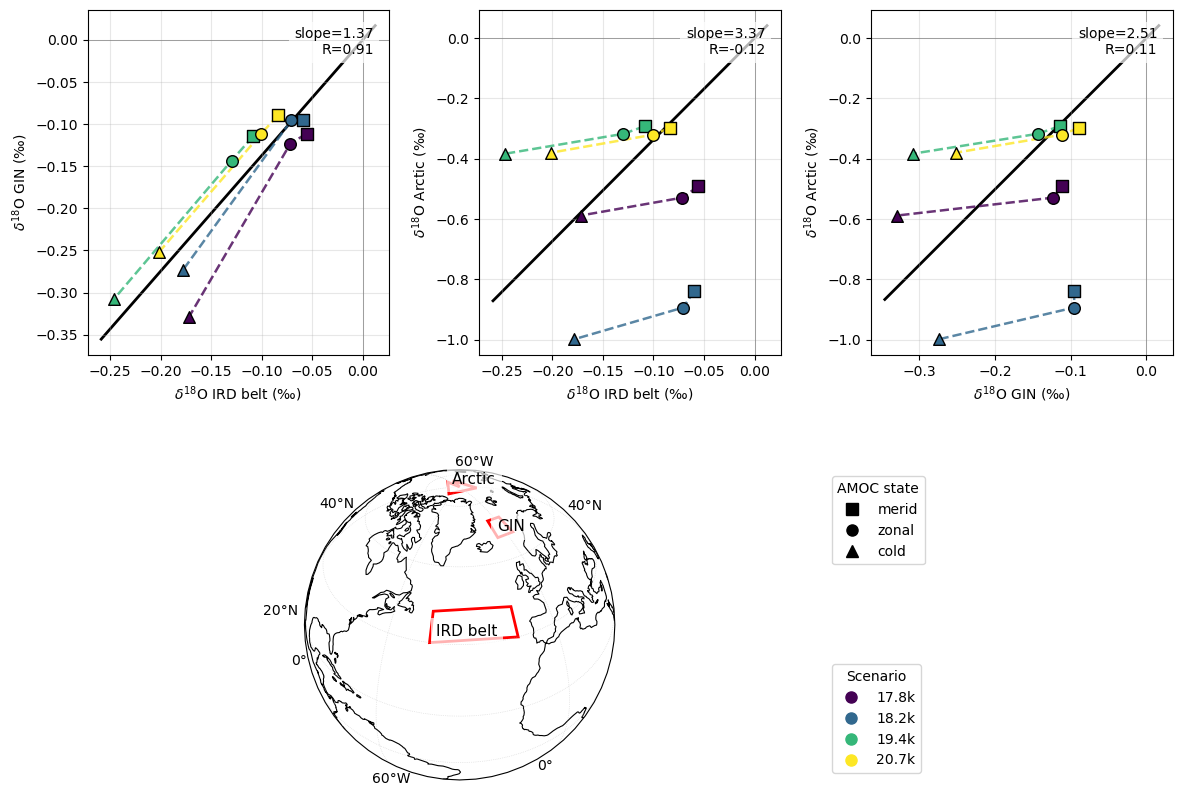

In [219]:
# predicted

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import matplotlib.patches as mpatches


# --------------------------------------------------
# SETTINGS
# --------------------------------------------------

snapshots = ['17.8k', '18.2k','19.4k', '20.7k']
states = ['merid','zonal','cold']

colors = plt.cm.viridis(np.linspace(0,1,len(snapshots)))


# region pairs for the three panels vs GIN
region_pairs = [
    ("IRD belt", "GIN"),
    ("IRD belt","Arctic"),
    ("GIN","Arctic")
]


# --------------------------------------------------
# FIGURE LAYOUT
# --------------------------------------------------

fig = plt.figure(figsize=(14,10))

gs = gridspec.GridSpec(
    nrows=2,
    ncols=3,
    height_ratios=[1,0.9],
    hspace=0.35,
    wspace=0.3
)


axes_scatter = [
    fig.add_subplot(gs[0,i])
    for i in range(3)
]


# --------------------------------------
# Bottom row: centered map + legend box
# --------------------------------------

gs_bottom = gridspec.GridSpecFromSubplotSpec(
    nrows=1,
    ncols=3,
    subplot_spec=gs[1,:],
    width_ratios=[0.01, 1, 0.5],   # empty | globe | legends
    wspace=0.05
)


# empty space left to center block
ax_empty = fig.add_subplot(gs_bottom[0])
ax_empty.axis("off")


# globe
projection_map = ccrs.NearsidePerspective(
    central_longitude=-35,
    central_latitude=45,
    satellite_height=11000000
)

ax_map = fig.add_subplot(
    gs_bottom[1],
    projection=projection_map
)


# legend container
ax_legend = fig.add_subplot(gs_bottom[2])
ax_legend.axis("off")


# --------------------------------------------------
# SCATTER PANELS
# --------------------------------------------------

for ax,(regx,regy) in zip(axes_scatter,region_pairs):

    x_all = []
    y_all = []

    for i,snap in enumerate(snapshots):

        color = colors[i]

        xvals=[]
        yvals=[]

        for state in states:

            x = comp_predict_lookup[regx][state][snap]
            y = comp_predict_lookup[regy][state][snap]

            xvals.append(x)
            yvals.append(y)

            x_all.append(x)
            y_all.append(y)


            ax.scatter(
                x,
                y,
                color=color,
                marker=state_markers[state],
                s=70,
                edgecolor="black",
                zorder=3
            )


        # connect AMOC states
        ax.plot(
            xvals,
            yvals,
            color=color,
            linestyle="--",
            linewidth=1.8,
            alpha=0.8
        )


    ax.axhline(0,color="grey",lw=0.5)
    ax.axvline(0,color="grey",lw=0.5)

    ax.grid(alpha=0.3)

    ax.set_xlabel(
        rf"$\delta^{{18}}$O {regx} (‰)"
    )

    ax.set_ylabel(
        rf"$\delta^{{18}}$O {regy} (‰)"
    )


    # -----------------------------
    # overall scaling relationship
    # -----------------------------
    
    slope, r = slope_through_origin(
        x_all,
        y_all
    )
    
    
    # plot slope line
    xmin,xmax=ax.get_xlim()
    
    xx=np.linspace(xmin,xmax,100)
    
    ax.plot(
        xx,
        slope*xx,
        color="black",
        linewidth=2,
        linestyle="-",
        zorder=1,
    )
    
    
    # annotate
    ax.text(
        0.95,
        0.95,
        f"slope={slope:.2f}\nR={r:.2f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(
            facecolor="white",
            alpha=0.7,
            edgecolor="none"
        )
    )




# --------------------------------------------------
# MAP PANEL
# --------------------------------------------------

#ax_map.set_extent(
#        [-100,25,20,90],
#    crs=ccrs.PlateCarree()
#)

ax_map.set_global()

ax_map.coastlines(
    linewidth=0.8
)


# region boundaries
for name,coords in regions.items():

    width = coords["lon_max"] - coords["lon_min"]
    height = coords["lat_max"] - coords["lat_min"]

    rect = mpatches.Rectangle(
        (coords["lon_min"],coords["lat_min"]),
        width,
        height,
        linewidth=2,
        edgecolor="red",
        facecolor="none",
        transform=ccrs.PlateCarree(),
        clip_on=False,
    )

    ax_map.add_patch(rect)

    ax_map.text(
        coords["lon_min"]+2,
        coords["lat_min"]+2,
        name,
        transform=ccrs.PlateCarree(),
        fontsize=11,
        bbox=dict(
            facecolor="white",
            alpha=0.7,
            edgecolor="none"
        )
    )


# grid
gl=ax_map.gridlines(
    draw_labels=True,
    linewidth=0.5,
    linestyle=":",
    alpha=0.5
)

gl.top_labels=False
gl.right_labels=False


# --------------------------------------------------
# LEGENDS
# --------------------------------------------------

state_handles=[
    plt.Line2D(
        [],
        [],
        marker=state_markers[s],
        color="k",
        linestyle="None",
        markersize=8,
        label=s
    )
    for s in states
]


scenario_handles=[
    plt.Line2D(
        [],
        [],
        marker="o",
        color=colors[i],
        linestyle="None",
        markersize=8,
        label=snapshots[i]
    )
    for i in range(len(snapshots))
]



legend1 = ax_legend.legend(
    handles=state_handles,
    loc="upper left",
    title="AMOC state",
    frameon=True,
)

ax_legend.add_artist(legend1)


ax_legend.legend(
    handles=scenario_handles,
    loc="lower left",
    title="Scenario",
    frameon=True,
)

plt.savefig("my_output/chapter-four_latestfigures/Fig4_Rev_Scatter_RegionCompared_predicted.pdf")